## 1. Load, merge, and align analysis data

In [1]:
import pandas as pd
import numpy as np

# =========================================================
# 1. LOAD DATA
# =========================================================

dat = pd.read_csv("r00_sample_characteristics.csv")
dat_combined = pd.read_csv("only_fcr_ratings.csv")
fmri_fast = pd.read_csv("Low_nonfood_fasted_77_subjects.csv")
fmri_fed  = pd.read_csv("High_nonfood_fed_79_subjects.csv")
asa24 = pd.read_csv("ASA24_mom_child.csv")

# Column names
dat_id_col = dat.columns[0]
comb_id_col = dat_combined.columns[0]
asa24_id_col = asa24.columns[0]
fmri_fast_id_col = fmri_fast.columns[0]
fmri_fed_id_col = fmri_fed.columns[0]


# =========================================================
# 2. CLEAN & ALIGN IDs
# =========================================================

# --- Clean dat IDs ---
dat[dat_id_col] = pd.to_numeric(dat[dat_id_col], errors="coerce")
dat = dat.dropna(subset=[dat_id_col])
dat[dat_id_col] = dat[dat_id_col].astype(int)

# If dat IDs are NOT already 2000-based, uncomment this:
dat[dat_id_col] = dat[dat_id_col] + 2000


# --- Clean fMRI IDs ---
fmri_fast["ID_tmp"] = pd.to_numeric(fmri_fast[fmri_fast_id_col], errors="coerce")
fmri_fed["ID_tmp"]  = pd.to_numeric(fmri_fed[fmri_fed_id_col], errors="coerce")

fmri_fast = fmri_fast.dropna(subset=["ID_tmp"])
fmri_fed  = fmri_fed.dropna(subset=["ID_tmp"])

fmri_fast["ID_tmp"] = fmri_fast["ID_tmp"].astype(int)
fmri_fed["ID_tmp"]  = fmri_fed["ID_tmp"].astype(int)


# --- Clean ASA24 IDs ---
asa24[asa24_id_col] = (
    asa24[asa24_id_col]
    .astype(str)
    .str.strip()
)

asa24[asa24_id_col] = pd.to_numeric(
    asa24[asa24_id_col],
    errors="coerce"
)

asa24 = asa24.dropna(subset=[asa24_id_col])

# ADD +2000 HERE (correct location)
asa24[asa24_id_col] = asa24[asa24_id_col].astype(int) + 2000


# =========================================================
# 3. RESTRICT TO SUBJECTS IN BOTH FAST & FED
# =========================================================

fast_ids = set(fmri_fast["ID_tmp"])
fed_ids  = set(fmri_fed["ID_tmp"])
common_ids = fast_ids.intersection(fed_ids)

dat = dat[dat[dat_id_col].isin(common_ids)].copy()
fmri_fast = fmri_fast[fmri_fast["ID_tmp"].isin(common_ids)].copy()
fmri_fed  = fmri_fed[fmri_fed["ID_tmp"].isin(common_ids)].copy()


# =========================================================
# 4. SORT FOR PERFECT ROW ALIGNMENT
# =========================================================

dat = dat.sort_values(dat_id_col).reset_index(drop=True)
fmri_fast = fmri_fast.sort_values("ID_tmp").reset_index(drop=True)
fmri_fed  = fmri_fed.sort_values("ID_tmp").reset_index(drop=True)


# =========================================================
# 5. MERGE ASA24 PERCENT EMPTY CALORIES
# =========================================================

asa24_small = asa24[[asa24_id_col, "c_percent_empty_calories"]].copy()

asa24_small = asa24_small.rename(columns={
    asa24_id_col: dat_id_col,
    "c_percent_empty_calories": "percent_empty_calories"
})

asa24_small[dat_id_col] = asa24_small[dat_id_col].astype(int)

dat = dat.merge(asa24_small, on=dat_id_col, how="left")


# =========================================================
# 6. VERIFY MERGE WORKED
# =========================================================

print("Total subjects:", len(dat))
print("Non-NaN percent_empty_calories:",
      dat["percent_empty_calories"].notna().sum())

# =========================================================
# 7. ADD WANTING VARIABLES
# =========================================================

def get_wanting(df, search, fasted, var_name, ratings_df):
    df = df.copy()
    id_colname = df.columns[0]

    # Ensure numeric IDs
    df[id_colname] = df[id_colname].astype(int)
    ratings_df = ratings_df.copy()
    ratings_df[comb_id_col] = pd.to_numeric(
        ratings_df[comb_id_col], errors="coerce"
    ).astype(int)

    # Keep only subjects present in df
    subject_ids = df[id_colname].unique()
    filt_ratings = ratings_df[
        ratings_df[comb_id_col].isin(subject_ids)
    ].copy()

    filt_ratings = filt_ratings.set_index(comb_id_col)
    df = df.set_index(id_colname)

    # Select matching columns
    cols = [
        c for c in filt_ratings.columns
        if (search in c) and (fasted in c)
    ]

    if len(cols) == 0:
        print(f"No columns found for {var_name}")
        df[var_name] = np.nan
    else:
        col_mean = filt_ratings[cols].mean(axis=1)
        df[var_name] = col_mean.reindex(df.index)

    return df.reset_index()


dat = get_wanting(dat, "fcr_LED", "fast", "wanting_LED_fast", dat_combined)
dat = get_wanting(dat, "fcr_LED", "fed",  "wanting_LED_fed",  dat_combined)
dat = get_wanting(dat, "fcr_HED", "fast", "wanting_HED_fast", dat_combined)
dat = get_wanting(dat, "fcr_HED", "fed",  "wanting_HED_fed",  dat_combined)


Total subjects: 75
Non-NaN percent_empty_calories: 75


## 2. Sample characteristics

In [2]:
dat_clean = dat.copy()

cont_vars = [
    "c_age",
    "c_fat_percent",
    "c_BMIz",
    "c_waist_in"

]
for col in cont_vars:
    dat_clean[col] = pd.to_numeric(dat_clean[col], errors="coerce")

table1_cont = dat_clean[cont_vars].agg(["mean", "std"]).T
table1_cont["mean_sd"] = table1_cont["mean"].round(2).astype(str) + " ± " + table1_cont["std"].round(2).astype(str)

print(table1_cont[["mean_sd"]])

cat_vars = [
    "gender",
    "c_race",
    "c_weight_group_3",
]

gender_map = {
    1: "Male",
    2: "Female"
}

race_map = {
    1: "American Indian / Alaska Native",
    2: "Asian",
    3: "Black or African American",
    4: "Native Hawaiian / Pacific Islander",
    5: "White",
    6: "More than one race",
    7: "Unknown / Not reported"
}

weight_map = {
    1: "Normal weight",
    2: "Overweight",
    3: "Obese"
}


dat_clean["gender"] = dat_clean["gender"].map(gender_map)
dat_clean["c_race"] = dat_clean["c_race"].map(race_map)
dat_clean["c_weight_group_3"] = dat_clean["c_weight_group_3"].map(weight_map)


def summarize_categorical(df, col):
    counts = df[col].value_counts(dropna=False)
    perc = df[col].value_counts(normalize=True, dropna=False) * 100

    out = pd.DataFrame({
        "Variable": col,
        "Level": counts.index,
        "n": counts.values,
        "%": perc.values.round(1)
    })

    out["Value"] = out["n"].astype(str) + " (" + out["%"].astype(str) + "%)"
    return out[["Variable", "Level", "Value"]]

table1_cat = pd.concat([summarize_categorical(dat_clean, c) for c in cat_vars])
print(table1_cat)

                     mean_sd
c_age           16.28 ± 1.28
c_fat_percent  23.99 ± 11.31
c_BMIz           0.64 ± 1.18
c_waist_in       32.3 ± 5.61
           Variable                      Level       Value
0            gender                     Female  40 (53.3%)
1            gender                       Male  35 (46.7%)
0            c_race                      White  42 (56.0%)
1            c_race  Black or African American  24 (32.0%)
2            c_race         More than one race    6 (8.0%)
3            c_race                      Asian    2 (2.7%)
4            c_race     Unknown / Not reported    1 (1.3%)
0  c_weight_group_3              Normal weight  42 (56.0%)
1  c_weight_group_3                      Obese  18 (24.0%)
2  c_weight_group_3                 Overweight  15 (20.0%)


## 3. Behavioral outcome distributions and tertile thresholds

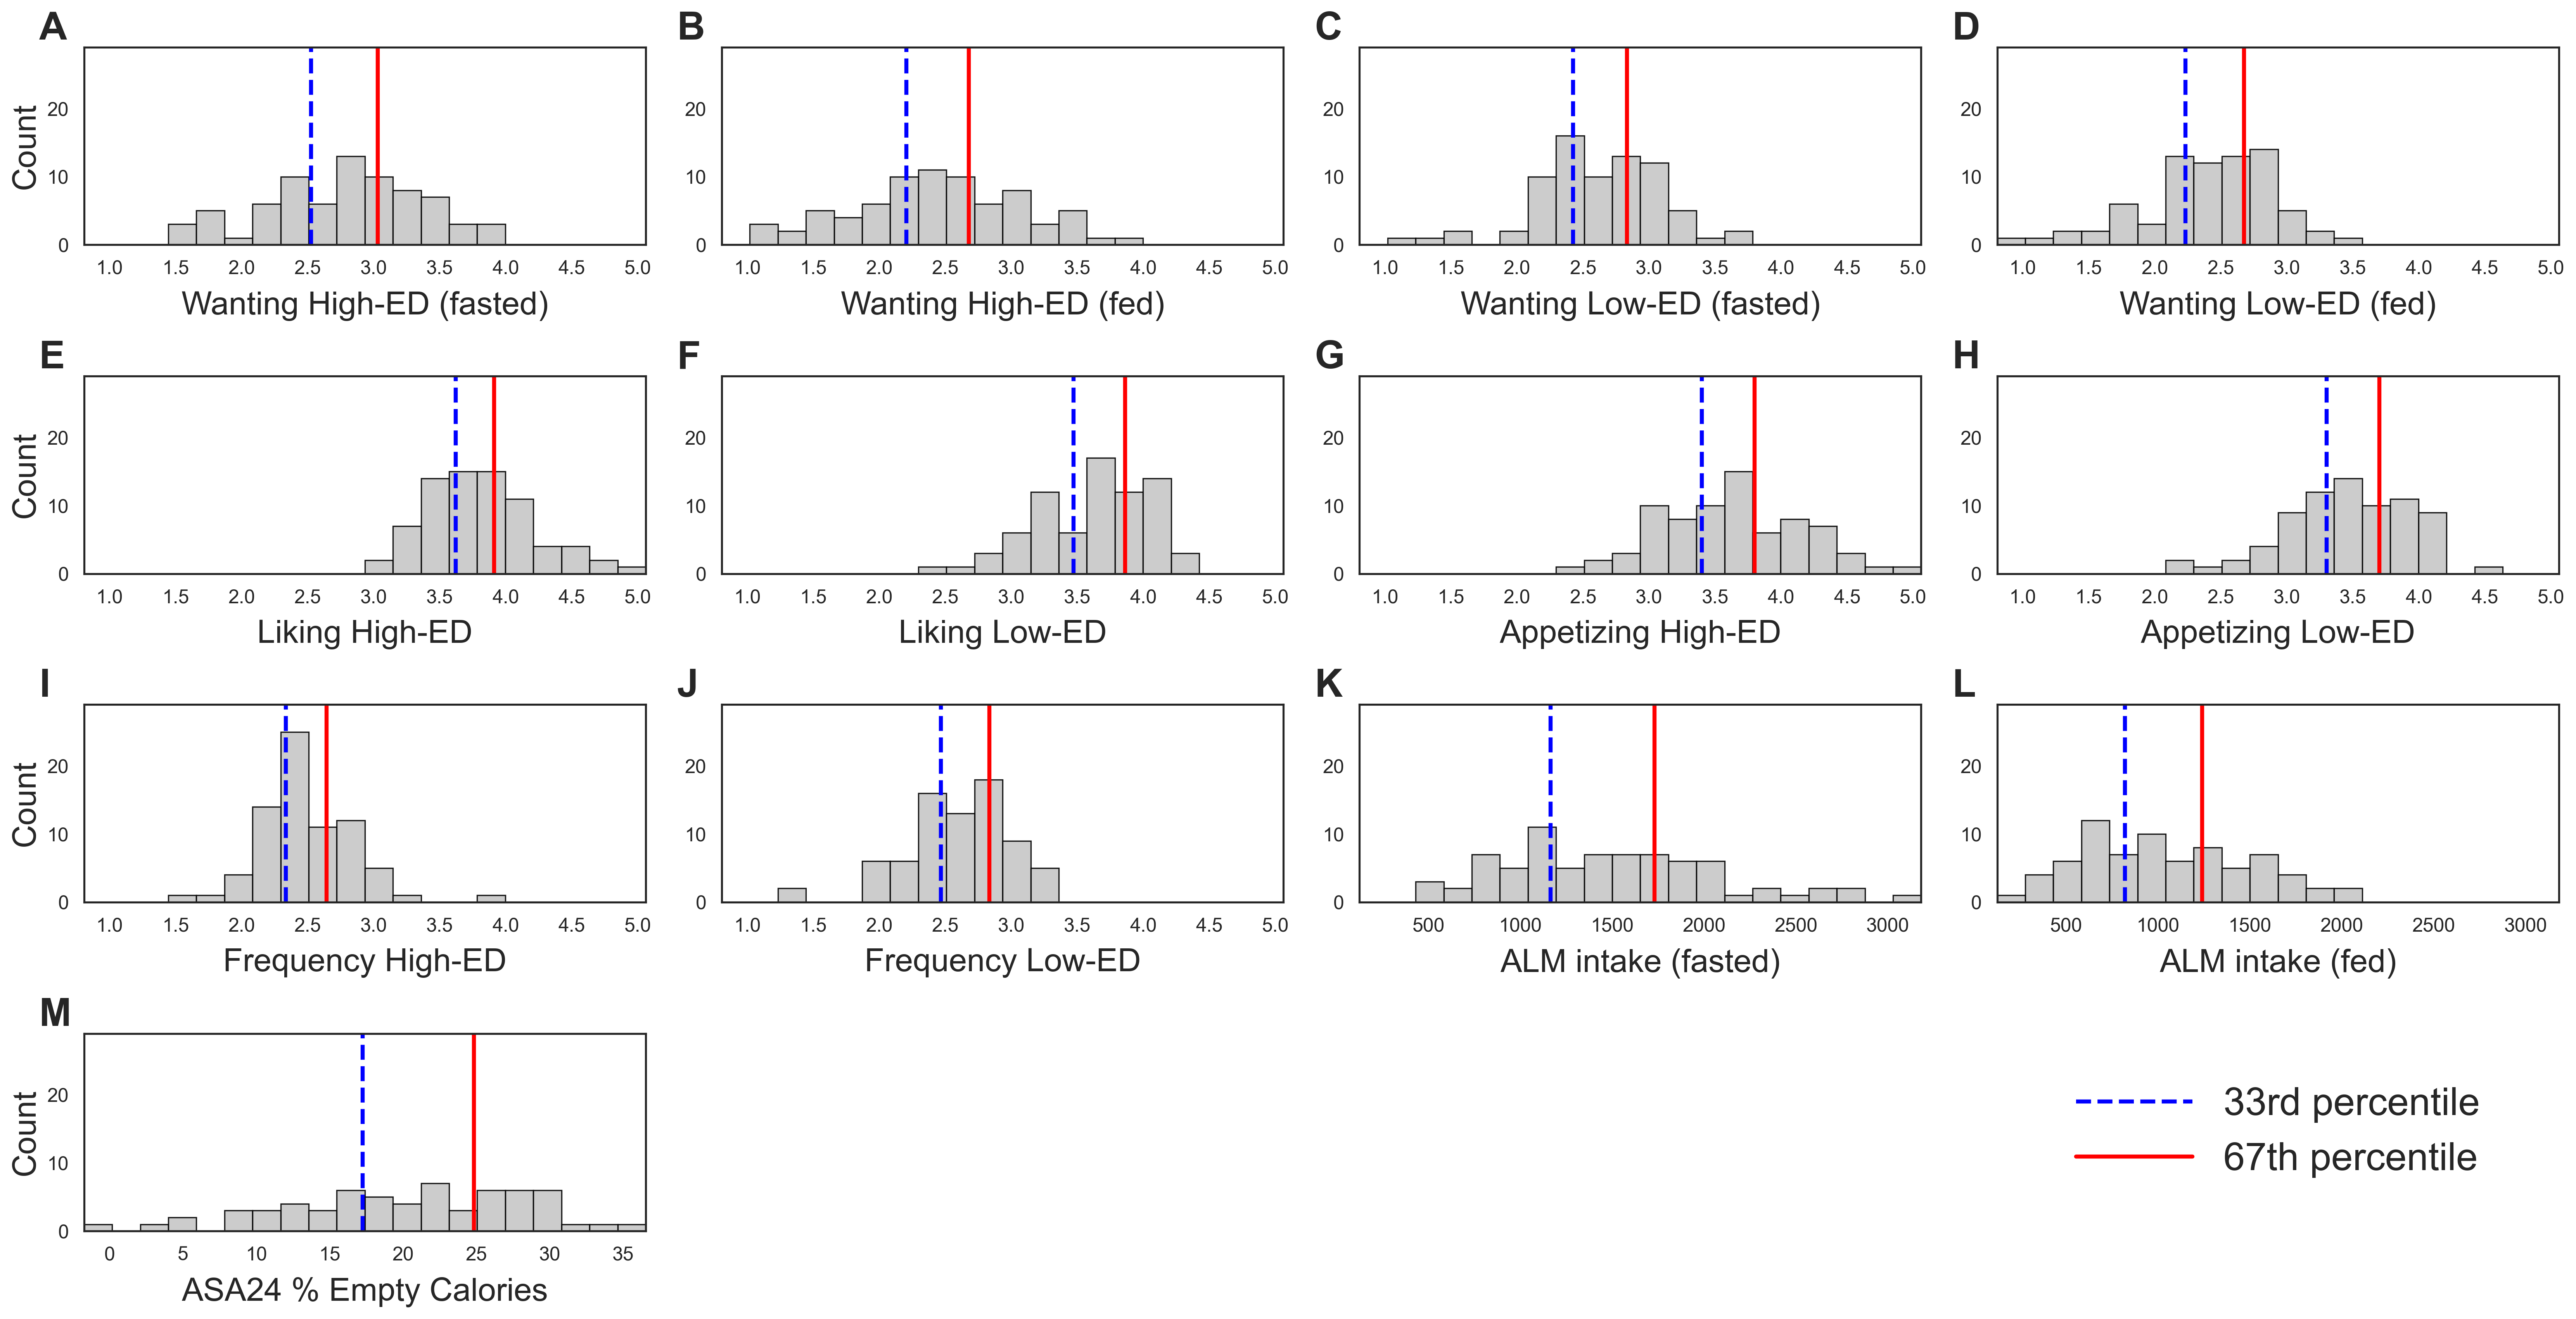

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import string

# Variables to plot
var2_name = [
    "wanting_HED_fast",
    "wanting_HED_fed",
    "wanting_LED_fast",
    "wanting_LED_fed",
    "mean_liking_HED_child",
    "mean_liking_LED_child",
    "mean_HED_appetizing_child",
    "mean_LED_appetizing_child",
    "mean_HED_frequency_child",
    "mean_LED_frequency_child",
    "fast_alm_kcal_w_drinks",
    "fed_alm_kcal_w_drinks",
    "percent_empty_calories"
]

# X-axis labels
title_names = {
    "mean_liking_HED_child": "Liking High-ED",
    "mean_liking_LED_child": "Liking Low-ED",
    "mean_HED_frequency_child": "Frequency High-ED",
    "mean_LED_frequency_child": "Frequency Low-ED",
    "mean_HED_appetizing_child": "Appetizing High-ED",
    "mean_LED_appetizing_child": "Appetizing Low-ED",
    "fed_alm_kcal_w_drinks": "ALM intake (fed)",
    "fast_alm_kcal_w_drinks": "ALM intake (fasted)",
    "wanting_LED_fed": "Wanting Low-ED (fed)",
    "wanting_LED_fast": "Wanting Low-ED (fasted)",
    "wanting_HED_fed": "Wanting High-ED (fed)",
    "wanting_HED_fast": "Wanting High-ED (fasted)",
    "percent_empty_calories": "ASA24 % Empty Calories"
}

# ---------------------------------------------------------
# Clean outcome variables
# ---------------------------------------------------------

for var in var2_name:
    dat[var] = (
        dat[var]
        .astype(str)
        .str.strip()
        .replace("", np.nan)
    )

    dat[var] = pd.to_numeric(
        dat[var],
        errors="coerce"
    )

# ---------------------------------------------------------
# Plot style
# ---------------------------------------------------------

sns.set_theme(style="white")

hist_color = "#C7C7C7"

# ---------------------------------------------------------
# Define groups that should share x-axis limits
# ---------------------------------------------------------

rating_vars = [
    "wanting_HED_fast",
    "wanting_HED_fed",
    "wanting_LED_fast",
    "wanting_LED_fed",
    "mean_liking_HED_child",
    "mean_liking_LED_child",
    "mean_HED_appetizing_child",
    "mean_LED_appetizing_child",
    "mean_HED_frequency_child",
    "mean_LED_frequency_child"
]

alm_vars = [
    "fast_alm_kcal_w_drinks",
    "fed_alm_kcal_w_drinks"
]

asa24_vars = [
    "percent_empty_calories"
]

groups = [
    rating_vars,
    alm_vars,
    asa24_vars
]

# ---------------------------------------------------------
# Calculate common x-axis limits within groups
# ---------------------------------------------------------

xlims = {}

for group in groups:

    all_vals = np.concatenate([
        dat[var].dropna().values
        for var in group
    ])

    xmin = np.nanmin(all_vals)
    xmax = np.nanmax(all_vals)

    xpad = (xmax - xmin) * 0.05

    group_xlim = (
        xmin - xpad,
        xmax + xpad
    )

    for var in group:
        xlims[var] = group_xlim

# ---------------------------------------------------------
# Determine common y-axis maximum
# ---------------------------------------------------------

max_count = 0

for var in var2_name:

    vals = dat[var].dropna()

    counts, _ = np.histogram(
        vals,
        bins=20,
        range=xlims[var]
    )

    max_count = max(
        max_count,
        counts.max()
    )

# Round upward a little for visual headroom
ymax = np.ceil(max_count * 1.15)

# ---------------------------------------------------------
# Grid layout
# ---------------------------------------------------------

n = len(var2_name)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.5 * ncols, 2.8 * nrows),
    dpi=300,
    constrained_layout=True
)

fig.set_constrained_layout_pads(
    w_pad=0.03,
    h_pad=0.03,
    wspace=0.04,
    hspace=0.06
)

axes = axes.flatten()

# ---------------------------------------------------------
# Plot each distribution
# ---------------------------------------------------------

for i, (ax, var) in enumerate(zip(axes, var2_name)):

    vals = dat[var].dropna()

    # Histogram
    ax.hist(
        vals,
        bins=20,
        range=xlims[var],
        color=hist_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9
    )

    # Tertile cutoffs
    q33 = np.nanpercentile(vals, 33.3333)
    q66 = np.nanpercentile(vals, 66.6667)

    ax.axvline(
        q33,
        color="blue",
        linestyle="--",
        linewidth=2.5
    )

    ax.axvline(
        q66,
        color="red",
        linestyle="-",
        linewidth=2.5
    )

    # Harmonized axes
    ax.set_xlim(xlims[var])
    ax.set_ylim(0, ymax)

    # -----------------------------------------------------
    # Panel label
    # -----------------------------------------------------

    ax.text(
        -0.08,
        1.00,
        string.ascii_uppercase[i],
        transform=ax.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="left"
    )

    # -----------------------------------------------------
    # Outcome name as X-axis label
    # -----------------------------------------------------

    ax.set_xlabel(
        title_names[var],
        fontsize=20,
        labelpad=8
    )

    # -----------------------------------------------------
    # Y-axis label only on left-most column
    # -----------------------------------------------------

    if i % ncols == 0:
        ax.set_ylabel(
            "Count",
            fontsize=20
        )
    else:
        ax.set_ylabel("")

    ax.tick_params(
        axis="both",
        labelsize=12
    )

    ax.grid(False)

# ---------------------------------------------------------
# Turn unused axes off
# ---------------------------------------------------------

for ax in axes[n:]:
    ax.axis("off")

# ---------------------------------------------------------
# Legend in unused bottom-right subplot
# ---------------------------------------------------------

legend_handles = [
    Line2D(
        [0], [0],
        color="blue",
        linestyle="--",
        linewidth=2.5,
        label="33rd percentile"
    ),
    Line2D(
        [0], [0],
        color="red",
        linestyle="-",
        linewidth=2.5,
        label="67th percentile"
    )
]

legend_ax = axes[-1]
legend_ax.axis("off")

legend_ax.legend(
    handles=legend_handles,
    loc="center",
    frameon=False,
    fontsize=24,
    handlelength=3
)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

plt.savefig(
    "distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Correlations among behavioral outcomes and covariates

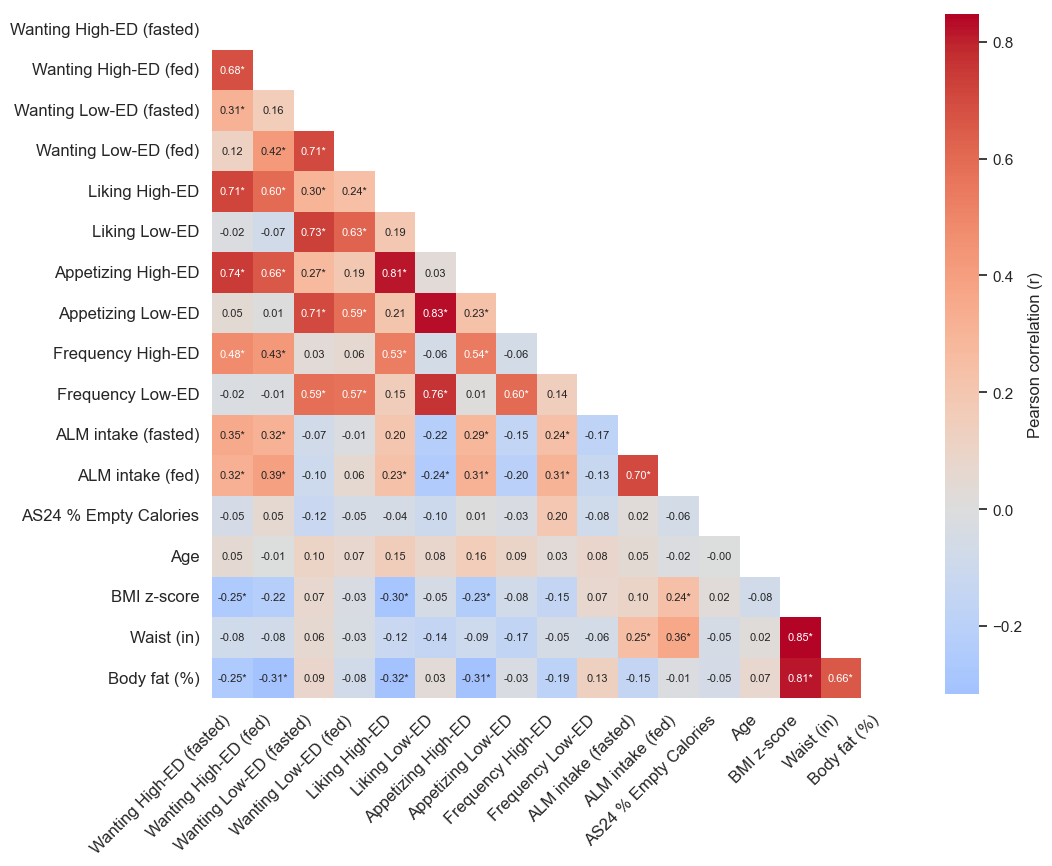

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

label_map = {
    # Outcomes
    "mean_liking_HED_child": "Liking High-ED",
    "mean_liking_LED_child": "Liking Low-ED",
    "mean_HED_frequency_child": "Frequency High-ED",
    "mean_LED_frequency_child": "Frequency Low-ED",
    "mean_HED_appetizing_child": "Appetizing High-ED",
    "mean_LED_appetizing_child": "Appetizing Low-ED",
    "fed_alm_kcal_w_drinks" : "ALM intake (fed)",
    "fast_alm_kcal_w_drinks" : "ALM intake (fasted)",
    "wanting_LED_fed": "Wanting Low-ED (fed)",
    "wanting_LED_fast": "Wanting Low-ED (fasted)",
    "wanting_HED_fed" : "Wanting High-ED (fed)",
    "wanting_HED_fast": "Wanting High-ED (fasted)",
    "percent_empty_calories": "AS24 % Empty Calories",

    # Covariates
    "c_age": "Age",
    "c_BMIz": "BMI z-score",
    "c_waist_in": "Waist (in)",
    "c_fat_percent": "Body fat (%)",
}

ordered_vars = [
    "wanting_HED_fast",
    "wanting_HED_fed",
    "wanting_LED_fast",
    "wanting_LED_fed",
    "mean_liking_HED_child",
    "mean_liking_LED_child",
    "mean_HED_appetizing_child",
    "mean_LED_appetizing_child",
    "mean_HED_frequency_child",
    "mean_LED_frequency_child",
    "fast_alm_kcal_w_drinks",
    "fed_alm_kcal_w_drinks",
    "percent_empty_calories"
]

covs = [
    "c_age",
    "c_BMIz",
    "c_waist_in",
    "c_fat_percent",

]

df_corr = dat.copy()

# Convert continuous
for col in ["c_age", "c_fat_percent", "c_BMIz", "c_waist_in"]:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

# -------------------------------
# Select variables
# -------------------------------
corr_vars = ordered_vars + covs
df_corr = df_corr[corr_vars]

# -------------------------------
# Compute correlation
# -------------------------------
df_corr = df_corr.replace(r"^\s*$", np.nan, regex=True)


corr = pd.DataFrame(index=corr_vars, columns=corr_vars, dtype=float)
pvals = pd.DataFrame(index=corr_vars, columns=corr_vars, dtype=float)

for var1 in corr_vars:
    for var2 in corr_vars:
        pair = df_corr[[var1, var2]].dropna()

        if var1 == var2:
            corr.loc[var1, var2] = 1
            pvals.loc[var1, var2] = 0

        elif len(pair) >= 3:
            r, p = pearsonr(pair[var1], pair[var2])
            corr.loc[var1, var2] = r
            pvals.loc[var1, var2] = p


corr = corr.rename(index=label_map, columns=label_map)
pvals = pvals.rename(index=label_map, columns=label_map)

# -------------------------------
# Annotation matrix
# * if p < 0.05
# -------------------------------

annot = corr.copy().astype(object)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        r = corr.iloc[i, j]
        p = pvals.iloc[i, j]

        if pd.isna(r):
            annot.iloc[i, j] = ""
        else:
            star = "*" if p < 0.05 else ""
            annot.iloc[i, j] = f"{r:.2f}{star}"

# -------------------------------
# Plot
# -------------------------------

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 10))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0,
    linecolor=None,
    annot=annot,
    fmt="",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": "Pearson correlation (r)", "shrink": 0.8},
    ax=ax
)

ax.grid(False)
ax.minorticks_off()

#plt.title("Correlation among outcomes and covariates", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("outcome_correlogram.png", dpi=300, bbox_inches="tight")
plt.savefig("outcome_correlogram.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [6]:
results = []

for i in range(len(corr.columns)):
    for j in range(i):
        results.append({
            "Variable 1": corr.index[i],
            "Variable 2": corr.columns[j],
            "r": corr.iloc[i, j],
            "p": pvals.iloc[i, j]
        })

corr_table = pd.DataFrame(results)

corr_table["abs_r"] = corr_table["r"].abs()
corr_table = corr_table.sort_values("abs_r", ascending=False)

# Print clean table
print(
    corr_table[
        ["Variable 1", "Variable 2", "r", "p"]
    ].to_string(
        index=False,
        formatters={
            "r": lambda x: f"{x:.2f}",
            "p": lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
        }
    )
)

             Variable 1               Variable 2     r      p
             Waist (in)              BMI z-score  0.85 <0.001
      Appetizing Low-ED            Liking Low-ED  0.83 <0.001
     Appetizing High-ED           Liking High-ED  0.81 <0.001
           Body fat (%)              BMI z-score  0.81 <0.001
       Frequency Low-ED            Liking Low-ED  0.76 <0.001
     Appetizing High-ED Wanting High-ED (fasted)  0.74 <0.001
          Liking Low-ED  Wanting Low-ED (fasted)  0.73 <0.001
         Liking High-ED Wanting High-ED (fasted)  0.71 <0.001
      Appetizing Low-ED  Wanting Low-ED (fasted)  0.71 <0.001
   Wanting Low-ED (fed)  Wanting Low-ED (fasted)  0.71 <0.001
       ALM intake (fed)      ALM intake (fasted)  0.70 <0.001
  Wanting High-ED (fed) Wanting High-ED (fasted)  0.68 <0.001
           Body fat (%)               Waist (in)  0.66 <0.001
     Appetizing High-ED    Wanting High-ED (fed)  0.66 <0.001
          Liking Low-ED     Wanting Low-ED (fed)  0.63 <0.001
       F

In [18]:
var2_name = [ 
    "mean_liking_HED_child", 
    "mean_liking_LED_child", 
    "mean_HED_frequency_child",
    "mean_LED_frequency_child", 
    "mean_HED_appetizing_child", 
    "mean_LED_appetizing_child", 
    "fed_alm_kcal_w_drinks", 
    "fast_alm_kcal_w_drinks", 
    "wanting_LED_fed", 
    "wanting_LED_fast", 
    "wanting_HED_fed", 
    "wanting_HED_fast", 
    "percent_empty_calories" ]

ROI_MAP = {
    1:"L Anterior Cingulate Gyrus", 2:"L Caudate", 3:"L Central Operculum", 4:"L Cuneus",
    5:"L Frontal Medial Cortex", 6:"L Frontal Operculum", 7:"L Frontal Orbital Cortex (1/2)",
    8:"L Frontal Orbital Cortex (2/2)", 9:"L Frontal Pole", 10:"L Hippocampus", 11:"L Insula (1/2)",
    12:"L Insula (2/2)", 13:"L Insula (posterior)", 14:"L Lingual Gyrus", 15:"L Midbrain",
    16:"L Middle Frontal Gyrus", 17:"L Nucleus Accumbens", 18:"L Pallidum",
    19:"L Paracingulate Gyrus", 20:"L Parietal Operculum Cortex",
    21:"L Posterior Cingulate Gyrus", 22:"L Precuneus", 23:"L Putamen",
    24:"L Superior Parietal Lobule", 25:"L Thalamus",
    26:"R Anterior Cingulate Gyrus", 27:"R Caudate", 28:"R Central Operculum", 29:"R Cuneus",
    30:"R Frontal Medial Cortex", 31:"R Frontal Operculum", 32:"R Frontal Orbital Cortex (1/2)",
    33:"R Frontal Orbital Cortex (2/2)", 34:"R Frontal Pole", 35:"R Hippocampus", 36:"R Insula (1/2)",
    37:"R Insula (2/2)", 38:"R Insula (Posterior)", 39:"R Lingual Gyrus", 40:"R Midbrain",
    41:"R Middle Frontal Gyrus", 42:"R Nucleus Accumbens", 43:"R Pallidum",
    44:"R Paracingulate Gyrus", 45:"R Parietal Operculum Cortex",
    46:"R Posterior Cingulate Gyrus", 47:"R Precuneus", 48:"R Putamen",
    49:"R Superior Parietal Lobule", 50:"R Thalamus",
}

import re

# ------------------------------------
# ROI parser
# Always extracts ROI number & returns unique label
# ------------------------------------
def feature_to_region_label(feature):
    s = str(feature)
    m = re.search(r"roi_(\d+)", s, flags=re.IGNORECASE)
    if m:
        idx = int(m.group(1))
        base = ROI_MAP.get(idx, f"ROI {idx}")
        return f"{base}"   # <-- UNIQUE LABEL
    return s

## 5. Exploratory train-only ROI–behavior associations

In [ ]:
import os, re
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.model_selection import RepeatedStratifiedKFold

# Parse region name -------
def feature_to_region_label(feature):
    m = re.search(r"roi[_-]?(\d+)", str(feature), flags=re.IGNORECASE)
    if m:
        idx = int(m.group(1))
        return ROI_MAP.get(idx, f"ROI {idx}")
    return str(feature)

def prior_correlations_train_only(
    X_df, y_cont, mode="tertile",
    n_splits=5, n_repeats=10, random_state=42
):
    """
    Computes train-only Pearson correlations per ROI within each CV fold,
    then aggregates across folds using Fisher z (atanh) averaging.
    Returns:
      prior_long: one row per ROI with mean r (Fisher-z), median r, SD of r, n_folds
      prior_wide_mean: a 1×ROIs dataframe of mean r (for quick plotting)
      per_fold_long: per-fold r and p-value (for stability diagnostics)
    """
    # align & drop NaNs in y
    y_cont = pd.to_numeric(pd.Series(y_cont), errors="coerce")
    valid = y_cont.notna()
    y_all = y_cont.loc[valid].astype(float)
    X_all = X_df.loc[valid].copy()

    # build labels for stratification
    if mode == "tertile":
        q33 = np.percentile(y_all, 33.3333)
        q67 = np.percentile(y_all, 66.6667)
        mask = (y_all <= q33) | (y_all >= q67)
        Xf = X_all.loc[mask]
        y_cont_f = y_all.loc[mask]
        y_strat = (y_all.loc[mask] >= q67).astype(int).values
    elif mode == "quartile":
        q75 = np.percentile(y_all, 75.0)
        Xf = X_all
        y_cont_f = y_all
        y_strat = (y_all >= q75).astype(int).values
    else:
        raise ValueError("mode must be 'tertile' or 'quartile'")

    if np.unique(y_strat).size < 2:
        raise ValueError("Only one class present after thresholding; choose another mode/variable.")

    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)

    roi_cols = list(Xf.columns)
    roi_pretty = [feature_to_region_label(c) for c in roi_cols]

    # per-fold correlations (train-only)
    per_fold_rows = []
    for fold_id, (tr, te) in enumerate(cv.split(Xf, y_strat), start=1):
        X_tr = Xf.iloc[tr, :]
        y_tr_cont = y_cont_f.iloc[tr]

        r_list, p_list = [], []
        for c in roi_cols:
            x = X_tr[c].values
            y = y_tr_cont.values
            # Handle degenerate variance to avoid pearsonr errors
            if np.all(np.isnan(x)) or np.nanstd(x) == 0 or np.nanstd(y) == 0:
                r, p = np.nan, np.nan
            else:
                r, p = pearsonr(x, y)
            r_list.append(r)
            p_list.append(p)

        per_fold_rows.append(pd.DataFrame({
            "fold": fold_id,
            "ROI_raw": roi_cols,
            "ROI": roi_pretty,
            "prior_r": r_list,
            "prior_p": p_list
        }))

    per_fold_long = pd.concat(per_fold_rows, ignore_index=True)

    # aggregate across folds using Fisher z
    def fisher_mean_r(r_vals):
        r_vals = np.array(r_vals, dtype=float)
        r_vals = r_vals[~np.isnan(r_vals)]
        if r_vals.size == 0:
            return np.nan, np.nan, 0
        # clip to avoid inf at |r|=1
        r_vals = np.clip(r_vals, -0.999999, 0.999999)
        z = np.arctanh(r_vals)
        z_mean = np.mean(z)
        r_mean = np.tanh(z_mean)
        r_median = np.median(r_vals)
        return r_mean, r_median, r_vals.size

    agg_rows = []
    for roi, g in per_fold_long.groupby("ROI", dropna=False):
        r_mean, r_median, n = fisher_mean_r(g["prior_r"].values)
        r_std = np.nanstd(g["prior_r"].values, ddof=1)
        agg_rows.append({
            "ROI": roi,
            "prior_r_mean": r_mean,      # Fisher-z averaged
            "prior_r_median": r_median,  # median of raw r
            "prior_r_std": r_std,        # SD across folds (raw r)
            "n_folds": n
        })

    prior_long = pd.DataFrame(agg_rows)
    prior_wide_mean = prior_long.set_index("ROI")[["prior_r_mean"]].T
    prior_wide_mean.index = ["prior_r_mean"]

    return prior_long, prior_wide_mean, per_fold_long

# Driver over all outcomes; saves tidy CSVs per outcome & combined -------
def run_all_prior_maps(X, dat, outcome_names, mode="tertile",
                       outdir="prior_corr_artifacts", random_state=42,
                       do_full_sample=False):
    os.makedirs(outdir, exist_ok=True)

    all_long = []
    for var in outcome_names:
        y_cont = dat[var]

        prior_long, prior_wide_mean, per_fold_long = prior_correlations_train_only(
            X_df=X, y_cont=y_cont, mode=mode, random_state=random_state
        )
        # tag and save
        prior_long.insert(0, "Outcome", var)
        per_fold_long.insert(0, "Outcome", var)

        prior_long.to_csv(os.path.join(outdir, f"{var}_prior_trainonly_agg.csv"), index=False)
        per_fold_long.to_csv(os.path.join(outdir, f"{var}_prior_trainonly_perfold.csv"), index=False)

        if do_full_sample:
            # Descriptive (full-sample) Spearman per ROI
            rhos = []
            roi_cols = list(X.columns)
            for c in roi_cols:
                rho, _ = spearmanr(X[c].values, pd.to_numeric(dat[var], errors="coerce").values, nan_policy="omit")
                rhos.append(rho)
            full_df = pd.DataFrame({"ROI": [feature_to_region_label(c) for c in roi_cols],
                                    "prior_full_rho": rhos})
            full_df.insert(0, "Outcome", var)
            full_df.to_csv(os.path.join(outdir, f"{var}_prior_fullsample.csv"), index=False)

        all_long.append(prior_long)

    # Combined long file for heatmaps (Outcome, ROI, prior_mean, prior_std, ...)
    combined = pd.concat(all_long, ignore_index=True)
    combined.to_csv(os.path.join(outdir, "prior_trainonly_agg_all_outcomes.csv"), index=False)
    return combined

X = fmri_fast.drop(["ID", "ID_tmp"], axis=1)
combined = run_all_prior_maps(
    X=X,
    dat=dat,
    outcome_names=[
        "mean_liking_HED_child", "mean_liking_LED_child",
        "mean_HED_frequency_child", "mean_LED_frequency_child",
        "mean_HED_appetizing_child", "mean_LED_appetizing_child",
        "fed_alm_kcal_w_drinks", "fast_alm_kcal_w_drinks",
        "wanting_LED_fast", "wanting_LED_fed",
        "wanting_HED_fast", "wanting_HED_fed",
        "percent_empty_calories"
    ],
    mode="tertile",              # or "quartile" to match that setup
    outdir="prior_corr_artifacts",
    random_state=42,
    do_full_sample=False         # set True to also export full-sample descriptive rhos
)



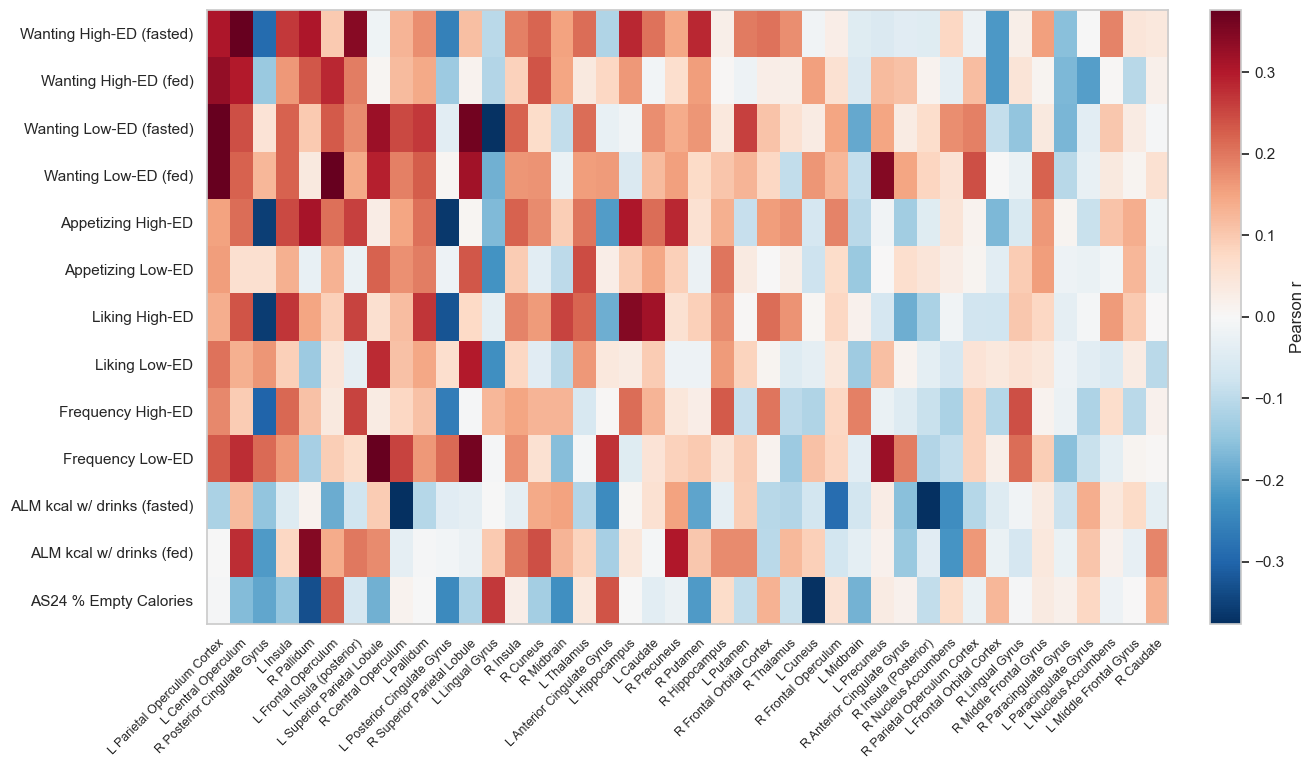

In [ ]:
def plot_prior_heatmap(combined_csv, value_col="prior_mean",
                       top_rois=30, normalize="row",
                       order_rows=False,    # also sort outcomes by overall |value|
                       outfile="prior_heatmap.png"):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.read_csv(combined_csv)

    # 1) keep top-N ROIs overall by |value|
    keep = (df.assign(val=df[value_col].abs())
              .groupby("ROI")["val"].sum()
              .sort_values(ascending=False)
              .index[:top_rois])
    dff = df[df["ROI"].isin(keep)].copy()

    # 2) pivot: rows=Outcome, cols=ROI
    pivot = (dff.pivot_table(index="Outcome", columns="ROI",
                             values=value_col, aggfunc="mean")
                 .fillna(0.0))
    desired_order = [
    
    "wanting_HED_fast",
    "wanting_HED_fed",
    "wanting_LED_fast",
    "wanting_LED_fed",

    "mean_HED_appetizing_child",
    "mean_LED_appetizing_child",
    "mean_liking_HED_child",
    "mean_liking_LED_child",
    "mean_HED_frequency_child",
    "mean_LED_frequency_child",
    
    "fast_alm_kcal_w_drinks",
    "fed_alm_kcal_w_drinks",
    "percent_empty_calories"
    ]

    # reindex the pivot rows with  specified order
    pivot = pivot.reindex(desired_order)

    # 3) order columns by average |value| across outcomes (strongest → weakest)
    roi_order = (pivot.abs().mean(axis=0)
                 .sort_values(ascending=False)
                 .index)
    pivot = pivot.loc[:, roi_order]

    if order_rows:
        row_order = (pivot.abs().mean(axis=1)
                     .sort_values(ascending=False)
                     .index)
        pivot = pivot.loc[row_order, :]


    # 4) normalization 
    M = pivot.values.astype(float)
    if normalize == "row":
        d = np.sum(np.abs(M), axis=1, keepdims=True)  # L1 (no sign cancellation)
        d[d == 0] = 1.0
        M = M / d
    elif normalize == "col":
        d = np.sum(np.abs(M), axis=0, keepdims=True)
        d[d == 0] = 1.0
        M = M / d
    elif normalize == "none":
        pass
    else:
        raise ValueError("normalize must be 'none'|'row'|'col'")

    # plot with robust symmetric limits (great for signed metrics like rhos)
    vmax = float(np.nanpercentile(np.abs(M), 99))
    if vmax == 0:  
        vmax = 1.0
    vmin = -vmax

    fig_w = max(8, 0.22 * M.shape[1] + 4)
    fig_h = max(6, 0.45 * M.shape[0] + 2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(M, aspect="auto", vmin=vmin, vmax=vmax, cmap="RdBu_r")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson r")

    title_names = {
        "mean_liking_HED_child": "Liking High-ED",
        "mean_liking_LED_child": "Liking Low-ED",
        "mean_HED_frequency_child": "Frequency High-ED",
        "mean_LED_frequency_child": "Frequency Low-ED",
        "mean_HED_appetizing_child": "Appetizing High-ED",
        "mean_LED_appetizing_child": "Appetizing Low-ED",
        "fed_alm_kcal_w_drinks" : "ALM kcal w/ drinks (fed)",
        "fast_alm_kcal_w_drinks" : "ALM kcal w/ drinks (fasted)",
        "wanting_LED_fed": "Wanting Low-ED (fed)",
        "wanting_LED_fast": "Wanting Low-ED (fasted)",
        "wanting_HED_fed" : "Wanting High-ED (fed)",
        "wanting_HED_fast": "Wanting High-ED (fasted)",
        "percent_empty_calories": "AS24 % Empty Calories"
    }

    ax.set_xticks(np.arange(M.shape[1]), labels=pivot.columns)
    y_labels = [title_names.get(idx, idx) for idx in pivot.index]

    ax.set_yticks(np.arange(M.shape[0]))
    ax.set_yticklabels(y_labels)

    for lab in ax.get_xticklabels():
        lab.set_rotation(45)
        lab.set_rotation_mode('anchor') 
        lab.set_ha('right')             
        lab.set_va('top')
        lab.set_fontsize(9)              

    fig.subplots_adjust(bottom=0.30)     

    ax.grid(False)

    fig.tight_layout()
    fig.savefig(outfile, dpi=300)
    fig.savefig("priors.pdf", dpi=300)
    plt.show()

    pivot.to_csv("prior_corr_artifacts/prior_heatmap_values_raw.csv")

    pd.DataFrame(M, index=pivot.index, columns=pivot.columns) \
    .to_csv("prior_corr_artifacts/prior_heatmap_values_displayed.csv")

plot_prior_heatmap(
    combined_csv="prior_corr_artifacts/prior_trainonly_agg_all_outcomes.csv",
    value_col="prior_r_mean",
    top_rois=45,
    normalize="none",
    outfile="prior_corr_artifacts/prior_heatmap_top30_rownorm_.png"
)

Print out R values for correlations

In [15]:
import pandas as pd

df = pd.read_csv(
    "prior_corr_artifacts/prior_trainonly_agg_all_outcomes.csv"
)

roi_summary = (
    df.groupby("ROI")["prior_r_mean"]
      .agg(["median", "min", "max", "mean"])
      .sort_values("median")
)

print(roi_summary)

                               median       min       max      mean
ROI                                                                
R Posterior Cingulate Gyrus -0.147118 -0.355954  0.212119 -0.106353
L Lingual Gyrus             -0.101801 -0.373079  0.265941 -0.071988
L Midbrain                  -0.068803 -0.192356  0.189360 -0.067696
L Frontal Orbital Cortex    -0.047976 -0.217198  0.126287 -0.061869
R Insula (Posterior)        -0.044348 -0.450131  0.081512 -0.062941
L Posterior Cingulate Gyrus -0.041190 -0.364248  0.213714 -0.107935
R Paracingulate Gyrus       -0.034513 -0.170770  0.017774 -0.071897
L Paracingulate Gyrus       -0.026652 -0.207288  0.138144 -0.023755
L Cuneus                    -0.014374 -0.373073  0.164953 -0.014239
R Nucleus Accumbens         -0.014049 -0.234271  0.174145 -0.024655
L Anterior Cingulate Gyrus   0.003591 -0.238026  0.270935 -0.006768
R Caudate                    0.003656 -0.100372  0.183769  0.020758
R Anterior Cingulate Gyrus   0.014680 -0.184136 

## 6. Univariate classification baselines

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pointbiserialr

def compute_pointbiserial_pipeline(X, y, mode="tertile"):
    """
    Point-biserial correlation aligned with your ML pipeline.
    X = feature matrix (e.g., fmri_fast)
    y = outcome (dat[var])
    """

    X = pd.DataFrame(X).copy()
    y = pd.to_numeric(pd.Series(y), errors="coerce")

    # Match  pipeline filtering
    valid = y.notna()
    X_all = X.loc[valid]
    y_all = y.loc[valid].astype(float)

    if mode == "tertile":
        q33 = np.percentile(y_all, 33.3333)
        q67 = np.percentile(y_all, 66.6667)

        mask = (y_all <= q33) | (y_all >= q67)
        Xf = X_all.loc[mask]
        y_bin = (y_all.loc[mask] >= q67).astype(int)

    else:
        raise ValueError("Only tertile supported")

    results = []

    for col in Xf.columns:
        x = pd.to_numeric(Xf[col], errors="coerce")

        valid = x.notna() & y_bin.notna()
        if valid.sum() < 10:
            continue

        r, p = pointbiserialr(y_bin[valid], x[valid])

        results.append({
            "ROI": col,
            "r_pb": r,
            "abs_r": abs(r),
            "p": p
        })

    res_df = pd.DataFrame(results).sort_values("abs_r", ascending=False)
    res_df["ROI_name"] = res_df["ROI"].apply(feature_to_region_label)
    return res_df



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score

def single_feature_auc_pipeline(X, y, mode="tertile", random_state=42):
    """
    Single-feature baseline AUC aligned with your ML pipeline.
    """

    X = pd.DataFrame(X).copy()
    y = pd.to_numeric(pd.Series(y), errors="coerce")

    # -------------------------------
    # Match  pipeline filtering
    valid = y.notna()
    X_all = X.loc[valid]
    y_all = y.loc[valid].astype(float)

    if mode == "tertile":
        q33 = np.percentile(y_all, 33.3333)
        q67 = np.percentile(y_all, 66.6667)

        mask = (y_all <= q33) | (y_all >= q67)
        Xf = X_all.loc[mask]
        yf = (y_all.loc[mask] >= q67).astype(int).values

    else:
        raise ValueError("Only tertile supported")

    cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=10,
        random_state=random_state
    )

    results = []

    for col in Xf.columns:
        x = pd.to_numeric(Xf[col], errors="coerce")

        valid = x.notna()
        if valid.sum() < 20:
            continue

        X_col = x[valid].values.reshape(-1, 1)
        y_col = yf[valid]

        aucs = []

        for tr, te in cv.split(X_col, y_col):
            model = LogisticRegression(solver="liblinear")

            model.fit(X_col[tr], y_col[tr])
            prob = model.predict_proba(X_col[te])[:, 1]

            auc = roc_auc_score(y_col[te], prob)
            aucs.append(auc)

        results.append({
            "ROI": col,
            "AUC_mean": np.mean(aucs),
            "AUC_std": np.std(aucs)
        })

    res_df = pd.DataFrame(results).sort_values("AUC_mean", ascending=False)
    res_df["ROI_name"] = res_df["ROI"].apply(feature_to_region_label)
    return res_df

In [18]:
X = fmri_fast.drop(["ID", "ID_tmp"], axis=1)

for var in var2_name:

    print(f"\n=== {var} ===")

    pb_df = compute_pointbiserial_pipeline(X, dat[var])
    auc_df = single_feature_auc_pipeline(X, dat[var])

    merged = pb_df.merge(auc_df, on="ROI", how="inner")

    print("\nTop correlations:")
    print(pb_df.head(10))

    print("\nTop baseline AUC:")
    print(auc_df.head(10))

    print("\nCombined:")
    print(merged.head(10))

    merged.to_csv(f"baseline_vs_pb_{var}.csv", index=False)


=== mean_liking_HED_child ===

Top correlations:
                                 ROI      r_pb     abs_r         p  \
0   roi_10_coords_-24_-39_-2_roi.mat  0.365729  0.365729  0.009005   
1    roi_11_coords_-38_7_-12_roi.mat  0.346665  0.346665  0.013652   
26    roi_37_coords_41_-8_-6_roi.mat  0.329147  0.329147  0.019595   
30   roi_40_coords_7_-20_-14_roi.mat  0.329043  0.329043  0.019637   
29     roi_3_coords_-50_-2_1_roi.mat  0.313033  0.313033  0.026866   
36    roi_46_coords_6_-37_27_roi.mat -0.304569  0.304569  0.031512   
3   roi_13_coords_-41_-17_-4_roi.mat  0.301619  0.301619  0.033281   
12   roi_21_coords_-6_-37_27_roi.mat -0.295001  0.295001  0.037549   
21     roi_2_coords_-10_14_9_roi.mat  0.277928  0.277928  0.050673   
8      roi_18_coords_-14_0_3_roi.mat  0.263591  0.263591  0.064373   

                       ROI_name  
0                 L Hippocampus  
1                      L Insula  
26                     R Insula  
30                   R Midbrain  
29       

## 7. Random Forest modeling with PCA

In [19]:
import os, pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone


def run_pca_cv(X, y, mode, n_components=20, random_state=42):
    """
    Runs repeated CV with PCA → RF classifier.
    Returns:
      - fold_df: per-fold metrics
      - summary: dict of mean/std metrics
      - fold_artifacts: list of dicts containing PCA + RF info for each fold
    """
    # Ensure DataFrame for consistent column handling
    X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
    roi_names = X.columns.tolist()

    # -----------------------------------------
    # Drop NaN in y
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    valid = y.notna()
    y_all = y.loc[valid].astype(float)
    X_all = X.loc[valid]

    # -----------------------------------------
    # Binarize label by mode
    if mode == "tertile":
        q33 = np.percentile(y_all, 33.3333)
        q67 = np.percentile(y_all, 66.6667)
        mask = (y_all <= q33) | (y_all >= q67)
        Xf = X_all.loc[mask]
        yf = (y_all.loc[mask] >= q67).astype(int).values

    elif mode == "quartile":
        q75 = np.percentile(y_all, 75.0)
        Xf = X_all
        yf = (y_all >= q75).astype(int).values

    else:
        raise ValueError("mode must be 'tertile' or 'quartile'")

    if np.unique(yf).size < 2:
        raise ValueError("Only one class present after thresholding.")

    # -----------------------------------------
    # CV schema
    cv = RepeatedStratifiedKFold(
        n_splits=5, n_repeats=10, random_state=random_state
    )

    # Define model pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            class_weight="balanced",
            random_state=123
        ))
    ])

    fold_rows = []
    fold_artifacts = []

    # -----------------------------------------
    # Run folds
    for fold_id, (tr, te) in enumerate(cv.split(Xf, yf), start=1):

        X_tr, X_te = Xf.iloc[tr, :], Xf.iloc[te, :]
        y_tr, y_te = yf[tr], yf[te]

        model = clone(pipe).fit(X_tr, y_tr)

        scaler = model.named_steps["scaler"]
        pca    = model.named_steps["pca"]
        rf     = model.named_steps["rf"]

        X_te_pca = pca.transform(scaler.transform(X_te))
        prob = rf.predict_proba(X_te_pca)[:, 1]

        auc = roc_auc_score(y_te, prob)
        pr  = average_precision_score(y_te, prob)

        fold_rows.append({
            "fold": fold_id,
            "AUC": auc,
            "PR_AUC": pr,
            "n_pc": X_te_pca.shape[1]
        })

        # store artifacts for later saving
        fold_artifacts.append({
            "fold_id": fold_id,
            "roi_names": roi_names,
            "test_index": te,
            "y_te": y_te,
            "X_te_pca": X_te_pca,
            "base_auc": auc,
            "pr_auc": pr,
            "pca_components": pca.components_,
            "pca_mean": pca.mean_,
            "pca_var_ratio": pca.explained_variance_ratio_,
            "rf_model": rf,
        })

    # Build fold summary df
    fold_df = pd.DataFrame(fold_rows)

    # Summary stats
    summary = {
        "AUC_mean": fold_df["AUC"].mean(),
        "AUC_std":  fold_df["AUC"].std(),
        "PR_AUC_mean": fold_df["PR_AUC"].mean(),
        "PR_AUC_std":  fold_df["PR_AUC"].std(),
        "n_pc_mean": fold_df["n_pc"].mean(),
        "n_pc_std":  fold_df["n_pc"].std(),
        "n_folds": len(fold_df)
    }

    return fold_df, summary, fold_artifacts


def run_all_outcomes_pca(X, dat, var_list, mode="tertile", save_root="outputs_pca"):
    os.makedirs(save_root, exist_ok=True)

    all_summary_rows = []
    all_folds_all = []

    for var in var_list:
        print(f"Running PCA CV for {var}")

        out_dir = os.path.join(save_root, var)
        folds_dir = os.path.join(out_dir, "folds")
        os.makedirs(folds_dir, exist_ok=True)

        fold_df, summary, fold_artifacts = run_pca_cv(
            X, dat[var], mode=mode
        )

        # Save fold-level metrics
        fold_df.to_csv(os.path.join(out_dir, "fold_summary.csv"), index=False)

        # Save each fold artifact
        for art in fold_artifacts:
            fid = art["fold_id"]
            with open(os.path.join(folds_dir, f"fold_{fid:03d}.pkl"), "wb") as f:
                pickle.dump(art, f)

        # Add to all-outcomes summary
        all_summary_rows.append({"Outcome": var, **summary})

        # Also tag folds for combined output (if needed)
        fold_df2 = fold_df.copy()
        fold_df2.insert(0, "Outcome", var)
        all_folds_all.append(fold_df2)

        print(f"Done: {var}")

    # Save combined summaries
    summary_df = pd.DataFrame(all_summary_rows)
    summary_df.to_csv(os.path.join(save_root, "all_outcomes_summary.csv"), index=False)

    combined_folds = pd.concat(all_folds_all, axis=0)
    combined_folds.to_csv(os.path.join(save_root, "all_folds_summary.csv"), index=False)

    return summary_df, combined_folds


X = fmri_fast.drop(["ID", "ID_tmp"], axis=1)

summary_df, fold_df = run_all_outcomes_pca(
    X,
    dat,
    var2_name,
    mode="tertile",
    save_root="pca_tert_fast_hed"
)


Running PCA CV for mean_liking_HED_child
Done: mean_liking_HED_child
Running PCA CV for mean_liking_LED_child
Done: mean_liking_LED_child
Running PCA CV for mean_HED_frequency_child
Done: mean_HED_frequency_child
Running PCA CV for mean_LED_frequency_child
Done: mean_LED_frequency_child
Running PCA CV for mean_HED_appetizing_child
Done: mean_HED_appetizing_child
Running PCA CV for mean_LED_appetizing_child
Done: mean_LED_appetizing_child
Running PCA CV for fed_alm_kcal_w_drinks
Done: fed_alm_kcal_w_drinks
Running PCA CV for fast_alm_kcal_w_drinks
Done: fast_alm_kcal_w_drinks
Running PCA CV for wanting_LED_fed
Done: wanting_LED_fed
Running PCA CV for wanting_LED_fast
Done: wanting_LED_fast
Running PCA CV for wanting_HED_fed
Done: wanting_HED_fed
Running PCA CV for wanting_HED_fast
Done: wanting_HED_fast
Running PCA CV for percent_empty_calories
Done: percent_empty_calories


## 8. Random Forest modeling with mutual-information feature selection

In [20]:
import os, pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score


def mi_score(X, y):
    return mutual_info_classif(X, y, random_state=0)

def run_cv(X, y, mode, save_root="outputs", random_state=42, k=30):
    """
    Runs CV and returns:
      - fold_df: AUCs for each fold
      - summary: mean/std metrics
      - fold_artifacts: list of dicts containing *all* per-fold objects
      - roi_names: list of features
    """
    os.makedirs(save_root, exist_ok=True)

    # Ensure DataFrame
    X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
    roi_names = list(X.columns)

    # Filter y
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    valid = y.notna()
    y_all = y.loc[valid].astype(float)
    X_all = X.loc[valid]

    # Threshold modes
    if mode == "tertile":
        q33 = np.percentile(y_all, 33.3333)
        q67 = np.percentile(y_all, 66.6667)
        mask = (y_all <= q33) | (y_all >= q67)
        Xf = X_all.loc[mask]
        yf = (y_all.loc[mask] >= q67).astype(int).values

    elif mode == "quartile":
        q75 = np.percentile(y_all, 75.0)
        Xf = X_all
        yf = (y_all >= q75).astype(int).values

    else:
        raise ValueError("mode must be 'tertile' or 'quartile'")

    if np.unique(yf).size < 2:
        raise ValueError("Only one class present after thresholding.")

    # Repeated Stratified K-Fold
    cv = RepeatedStratifiedKFold(
        n_splits=5, n_repeats=10, random_state=random_state
    )

    # Model pipeline
    pipe_template = Pipeline([
        ("scaler", StandardScaler()),
        ("kbest", SelectKBest(score_func=mi_score, k=k)),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            class_weight="balanced",
            random_state=123
        ))
    ])

    fold_rows = []
    fold_artifacts = []

    # Run folds
    for fold_id, (tr, te) in enumerate(cv.split(Xf, yf), 1):
        X_tr, X_te = Xf.iloc[tr, :], Xf.iloc[te, :]
        y_tr, y_te = yf[tr], yf[te]

        pipe = clone(pipe_template).fit(X_tr, y_tr)

        scaler = pipe.named_steps["scaler"]
        kbest  = pipe.named_steps["kbest"]
        rf     = pipe.named_steps["rf"]

        X_te_sel = kbest.transform(scaler.transform(X_te))
        prob_te = rf.predict_proba(X_te_sel)[:, 1]

        auc = roc_auc_score(y_te, prob_te)
        prauc = average_precision_score(y_te, prob_te)

        sel_idx = kbest.get_support(indices=True)
        sel_names = [roi_names[i] for i in sel_idx]

        # Store everything for post-hoc SHAP + permutation
        fold_artifacts.append({
            "fold_id": fold_id,
            "selected_idx": sel_idx,
            "selected_names": sel_names,
            "rf_model": rf,
            "scaler": scaler,
            "kbest": kbest,
            "X_te_sel": X_te_sel,
            "y_te": y_te,
        })

        # Save fold results (for summary)
        fold_rows.append({
            "fold": fold_id,
            "AUC": auc,
            "PR_AUC": prauc,
            "n_selected": len(sel_idx)
        })

    # -------------------------------
    # Fold summary
    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "AUC_mean": fold_df["AUC"].mean(),
        "AUC_std":  fold_df["AUC"].std(),
        "PR_AUC_mean": fold_df["PR_AUC"].mean(),
        "PR_AUC_std":  fold_df["PR_AUC"].std(),
        "n_folds": len(fold_df)
    }

    return fold_df, summary, fold_artifacts, roi_names



#     Pipeline for All Outcomes

def run_all_outcomes(X, dat, var_list, mode="tertile", save_root="outputs"):
    os.makedirs(save_root, exist_ok=True)

    all_summary_rows = []
    all_selection_indices = []

    for var in var_list:
        print(f"Running CV for {var}")

        out_dir = os.path.join(save_root, var)
        folds_dir = os.path.join(out_dir, "folds")
        os.makedirs(folds_dir, exist_ok=True)

        fold_df, summary, fold_artifacts, roi_names = run_cv(
            X, dat[var], mode=mode, save_root=out_dir
        )

        # Save fold summary
        fold_df.to_csv(os.path.join(out_dir, "fold_summary.csv"), index=False)

        # Save artifacts for each fold
        for art in fold_artifacts:
            fid = art["fold_id"]
            with open(os.path.join(folds_dir, f"fold_{fid:03d}.pkl"), "wb") as f:
                pickle.dump(art, f)

        # Add to summary table
        all_summary_rows.append({"Outcome": var, **summary})

        # Collect for ROI frequency
        for art in fold_artifacts:
            all_selection_indices.extend(art["selected_idx"])

        print(f"Done: {var}")

    # -------------------------------
    # Save overall outcome summaries
    summary_df = pd.DataFrame(all_summary_rows)
    summary_df.to_csv(os.path.join(save_root, "all_outcomes_summary.csv"), index=False)

    # -------------------------------
    # ROI selection frequency
    freq_df = compute_roi_frequency(all_selection_indices, roi_names)
    freq_df.to_csv(os.path.join(save_root, "roi_selection_frequency.csv"), index=False)

    return summary_df, freq_df


#         ROI Frequency Function

def compute_roi_frequency(all_selected_indices, roi_names):
    counts = {roi: 0 for roi in roi_names}

    for idx in all_selected_indices:
        counts[roi_names[idx]] += 1

    total_folds = len(all_selected_indices)

    freq_df = (
        pd.DataFrame.from_dict(counts, orient="index", columns=["n_selected"])
        .assign(freq=lambda d: d["n_selected"] / total_folds)
        .reset_index().rename(columns={"index": "ROI"})
        .sort_values("freq", ascending=False)
    )
    return freq_df


#         Run Pipeline

X = fmri_fast.drop(["ID", "ID_tmp"], axis=1)
summary_df, freq_df = run_all_outcomes(
    X,
    dat,
    var2_name,
    mode="tertile",
    save_root="selectk_tert_fast_led_v2"
)


Running CV for mean_liking_HED_child
Done: mean_liking_HED_child
Running CV for mean_liking_LED_child
Done: mean_liking_LED_child
Running CV for mean_HED_frequency_child
Done: mean_HED_frequency_child
Running CV for mean_LED_frequency_child
Done: mean_LED_frequency_child
Running CV for mean_HED_appetizing_child
Done: mean_HED_appetizing_child
Running CV for mean_LED_appetizing_child
Done: mean_LED_appetizing_child
Running CV for fed_alm_kcal_w_drinks
Done: fed_alm_kcal_w_drinks
Running CV for fast_alm_kcal_w_drinks
Done: fast_alm_kcal_w_drinks
Running CV for wanting_LED_fed
Done: wanting_LED_fed
Running CV for wanting_LED_fast
Done: wanting_LED_fast
Running CV for wanting_HED_fed
Done: wanting_HED_fed
Running CV for wanting_HED_fast
Done: wanting_HED_fast
Running CV for percent_empty_calories
Done: percent_empty_calories


## 9. Permutation feature importance

In [21]:
from sklearn.metrics import roc_auc_score
import numpy as np

def permutation_drop_auc(rf, X, y, n_repeats=5, random_state=0):
    """
    Computes permutation drop in AUC for each column of X.
    Returns: array of length n_features with mean AUC drop per feature.
    """
    rng = np.random.default_rng(random_state)

    # baseline performance
    base_auc = roc_auc_score(y, rf.predict_proba(X)[:, 1])

    n_features = X.shape[1]
    drops = np.zeros((n_repeats, n_features))

    for r in range(n_repeats):
        Xp = X.copy()
        for j in range(n_features):
            # Permute this ROI column
            Xp[:, j] = rng.permutation(X[:, j])

            # Compute drop
            auc_p = roc_auc_score(y, rf.predict_proba(Xp)[:, 1])
            drops[r, j] = base_auc - auc_p

            # Restore column for next permutation
            Xp[:, j] = X[:, j]

    return drops.mean(axis=0)

import os, pickle
import pandas as pd
import numpy as np

def load_perm_for_outcome(root, outcome, n_repeats=5):
    folds_dir = os.path.join(root, outcome, "folds")
    files = sorted([f for f in os.listdir(folds_dir) if f.endswith(".pkl")])

    rows = []

    for fname in files:
        with open(os.path.join(folds_dir, fname), "rb") as f:
            d = pickle.load(f)

        rf = d["rf_model"]
        X = d["X_te_sel"]          # (n_test, k)
        y = d["y_te"]
        sel_names = d["selected_names"]

        # Compute permutation importance for this fold
        drop_auc_vec = permutation_drop_auc(
            rf,
            X,
            y,
            n_repeats=n_repeats,
            random_state=0
        )

        df = pd.DataFrame({
            "ROI": sel_names,
            "drop_auc": drop_auc_vec
        })

        rows.append(df)

    # Aggregate across folds
    return (
        pd.concat(rows)
        .groupby("ROI")["drop_auc"]
        .mean()
    )


def build_perm_matrix(root, outcome_list, n_repeats=5):
    tables = []
    for outcome in outcome_list:
        print("Processing:", outcome)
        s = load_perm_for_outcome(root, outcome, n_repeats=n_repeats)
        s.name = outcome
        tables.append(s)

    # Combine outcome Series into ROI × Outcome matrix
    M = pd.concat(tables, axis=1).fillna(0)
    return M


root_dir = "selectk_tert_fast_led_v2"
outcome_list = var2_name

perm_matrix = build_perm_matrix(root_dir, outcome_list, n_repeats=5)

perm_matrix.to_csv("permutation_importance_matrix.csv")
print("Saved permutation_importance_matrix.csv")

perm_named = perm_matrix.rename(index=ROI_MAP)
perm_named.to_csv("permutation_importance_matrix_named.csv")


Processing: mean_liking_HED_child
Processing: mean_liking_LED_child
Processing: mean_HED_frequency_child
Processing: mean_LED_frequency_child
Processing: mean_HED_appetizing_child
Processing: mean_LED_appetizing_child
Processing: fed_alm_kcal_w_drinks
Processing: fast_alm_kcal_w_drinks
Processing: wanting_LED_fed
Processing: wanting_LED_fast
Processing: wanting_HED_fed
Processing: wanting_HED_fast
Processing: percent_empty_calories
Saved permutation_importance_matrix.csv


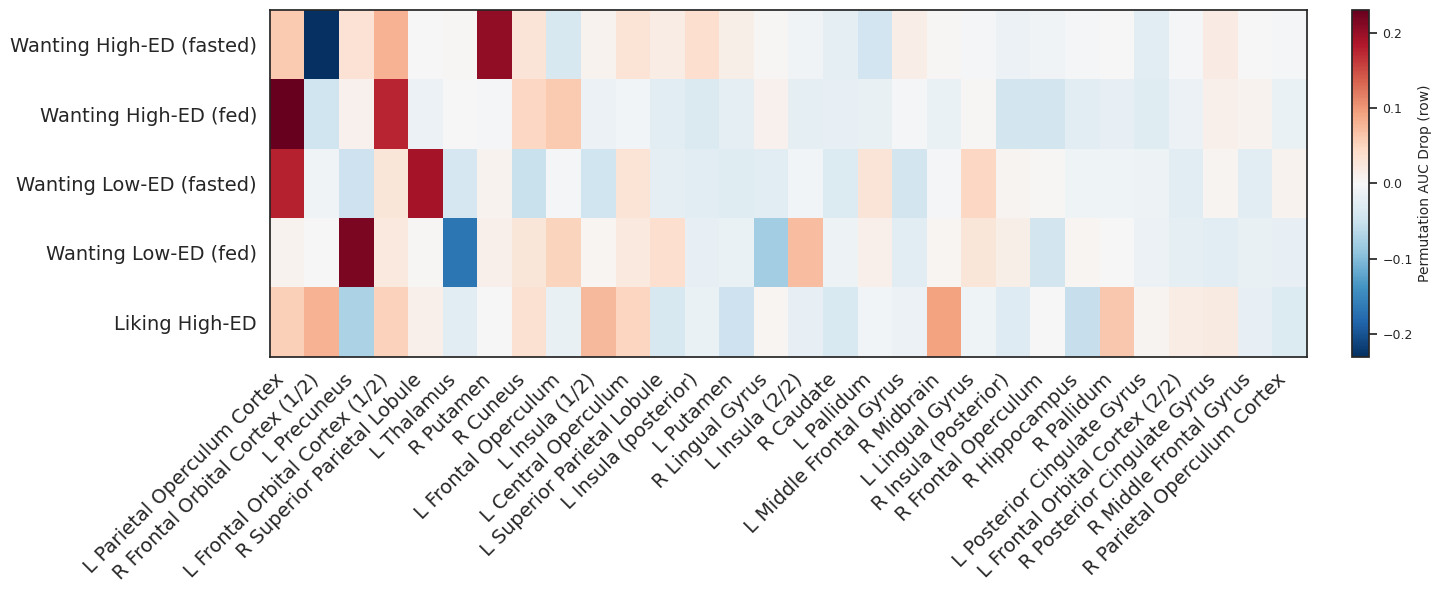

Saved heatmap to: perm_heatmap_selected.png


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re


# ------------------------------------
def feature_to_region_label(feature):
    s = str(feature)
    m = re.search(r"roi_(\d+)", s, flags=re.IGNORECASE)
    if m:
        idx = int(m.group(1))
        base = ROI_MAP.get(idx, f"ROI {idx}")
        return f"{base}"   # <-- UNIQUE LABEL
    return s


# ------------------------------------
# HEATMAP
# ------------------------------------
def plot_perm_heatmap(csv_path,
                       outcomes_to_include,
                       outfile="perm_heatmap.png",
                       normalize="none",
                       order_rows=True,
                       title_names=None):

    # Load permutation importance matrix (ROI × outcome)
    M = pd.read_csv(csv_path, index_col=0)

    # Filter outcomes (columns)
    keep = [col for col in outcomes_to_include if col in M.columns]
    M = M[keep]

    # Rename ROIs with UNIQUE labels
    M.index = [feature_to_region_label(idx) for idx in M.index]

    # Pivot for heatmap → rows: outcomes, columns: ROIs
    pivot = M.T.copy()

    # Order ROIs by average absolute importance
    n_rois = 30

    roi_order = (
        pivot.abs()
        .mean(axis=0)
        .sort_values(ascending=False)
        .head(n_rois)
        .index
    )

    pivot = pivot[roi_order]

    if order_rows:
        row_order = pivot.abs().mean(axis=1).sort_values(ascending=False).index
        pivot = pivot.loc[row_order]

    # Replace row names with human-readable ones
    if title_names:
        pivot.index = [title_names.get(o, o) for o in pivot.index]

    # Normalization
    A = pivot.values.astype(float)

    if normalize == "row":
        d = np.sum(np.abs(A), axis=1, keepdims=True)
        d[d == 0] = 1
        A = A / d
    elif normalize == "col":
        d = np.sum(np.abs(A), axis=0, keepdims=True)
        d[d == 0] = 1
        A = A / d
    elif normalize == "none":
        pass
    else:
        raise ValueError("normalize must be 'none', 'row', or 'col'")

    # Color scaling
    vmax = float(np.nanpercentile(np.abs(A), 99))
    vmin = -vmax if vmax != 0 else -1

    # Plotting
    fig_w = max(8, 0.35 * A.shape[1] + 4)
    fig_h = max(6, 0.45 * A.shape[0] + 2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.grid(False)

    im = ax.imshow(A, cmap="RdBu_r", aspect="auto", vmin=vmin, vmax=vmax)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Permutation AUC Drop" + (f" ({normalize})" if normalize != "none" else ""))

    # ticks
    ax.set_xticks(np.arange(A.shape[1]))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=14)

    ax.set_yticks(np.arange(A.shape[0]))
    ax.set_yticklabels(pivot.index, fontsize=14)

    fig.subplots_adjust(bottom=0.30)
    fig.tight_layout()
    fig.savefig(outfile, dpi=300)
    plt.show()

    # Save raw + plotted versions
    pivot.to_csv(outfile.replace(".png", "_raw.csv"))
    pd.DataFrame(A, index=pivot.index, columns=pivot.columns).to_csv(
        outfile.replace(".png", "_displayed.csv")
    )

    print(f"Saved heatmap to: {outfile}")

outcomes_to_include = [ "wanting_HED_fast", "wanting_HED_fed", "wanting_LED_fast", "wanting_LED_fed", "mean_liking_HED_child"] 
title_names = { "wanting_HED_fast": "Wanting High-ED (fasted)", "wanting_LED_fast": "Wanting Low-ED (fasted)", "wanting_HED_fed": "Wanting High-ED (fed)", "wanting_LED_fed": "Wanting Low-ED (fed)", "mean_liking_HED_child": "Liking High-ED", } 
plot_perm_heatmap( csv_path="permutation_importance_matrix_named.csv", outcomes_to_include=outcomes_to_include, outfile="perm_heatmap_selected.png", normalize="row", title_names=title_names, order_rows=False)

## 10. SHAP directionality analysis

In [27]:
import os, pickle
import numpy as np
import pandas as pd
import shap

def mi_score(X, y):
    from sklearn.feature_selection import mutual_info_classif
    return mutual_info_classif(X, y, random_state=0)

def rewrite_roi_name(raw, roi_map):
    """
    Convert any ROI label to the official name using ROI_MAP.
    Handles:
    - strings containing digits
    - pure digits
    - labels that match keys directly
    """
    # Case 1: numeric key directly
    if isinstance(raw, int):
        return roi_map.get(raw, raw)

    # Case 2: extract any integer inside the string
    import re
    nums = re.findall(r"\d+", str(raw))
    if len(nums) > 0:
        idx = int(nums[0])
        return roi_map.get(idx, raw)

    # Case 3: fallback = leave unchanged
    return raw


def run_shap_from_pkls(save_root, outcome_name):
    out_dir = os.path.join(save_root, outcome_name)
    folds_dir = os.path.join(out_dir, "folds")
    files = sorted([f for f in os.listdir(folds_dir) if f.endswith(".pkl")])

    shap_tables = []

    for fname in files:
        print("Processing:", fname)

        with open(os.path.join(folds_dir, fname), "rb") as f:
            art = pickle.load(f)

        rf = art["rf_model"]
        X_te_sel = art["X_te_sel"]
        sel_names = art["selected_names"]

        X_df = pd.DataFrame(X_te_sel, columns=sel_names)

        explainer = shap.TreeExplainer(
            rf,
            feature_perturbation="tree_path_dependent"
        )
        shap_vals = explainer.shap_values(X_df)

        # --- YOUR CASE: (samples, features, class_outputs) ---
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        elif shap_vals.ndim == 3 and shap_vals.shape[2] == 2:
            shap_vals = shap_vals[:, :, 1]
        elif shap_vals.ndim != 2:
            raise ValueError(f"Unexpected SHAP shape: {shap_vals.shape}")

        # verify dimensions
        if shap_vals.shape[1] != len(sel_names):
            raise ValueError(
                f"Mismatch: SHAP features={shap_vals.shape[1]}, sel_names={len(sel_names)}"
            )

        # directional SHAP 
        mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
        mean_shap = np.mean(shap_vals, axis=0)      # signed directionality
        sign = np.sign(mean_shap)                   # +1 or -1 or 0

        df = pd.DataFrame({
            "ROI": sel_names,
            "mean_abs_shap": mean_abs_shap,
            "mean_shap": mean_shap,
            "direction_sign": sign
        })

        shap_tables.append(df)

    # aggregate across folds 
    shap_all = pd.concat(shap_tables, ignore_index=True)

    shap_agg = (
        shap_all.groupby("ROI")[["mean_abs_shap", "mean_shap"]]
        .mean()
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index()
    )

    # sign = sign(mean_shap across folds)
    shap_agg["direction_sign"] = np.sign(shap_agg["mean_shap"])

    shap_agg["ROI"] = shap_agg["ROI"].apply(lambda x: rewrite_roi_name(x, ROI_MAP))

    outfile = os.path.join(out_dir, f"shap_{outcome_name}_rf_tertiles.csv")
    shap_agg.to_csv(outfile, index=False)
    print("Saved:", outfile)

    return shap_agg

run_shap_from_pkls(
    save_root = "selectk_tert_fast_led_v2",
    outcome_name = "wanting_LED_fed"
)




Processing: fold_001.pkl
Processing: fold_002.pkl
Processing: fold_003.pkl
Processing: fold_004.pkl
Processing: fold_005.pkl
Processing: fold_006.pkl
Processing: fold_007.pkl
Processing: fold_008.pkl
Processing: fold_009.pkl
Processing: fold_010.pkl
Processing: fold_011.pkl
Processing: fold_012.pkl
Processing: fold_013.pkl
Processing: fold_014.pkl
Processing: fold_015.pkl
Processing: fold_016.pkl
Processing: fold_017.pkl
Processing: fold_018.pkl
Processing: fold_019.pkl
Processing: fold_020.pkl
Processing: fold_021.pkl
Processing: fold_022.pkl
Processing: fold_023.pkl
Processing: fold_024.pkl
Processing: fold_025.pkl
Processing: fold_026.pkl
Processing: fold_027.pkl
Processing: fold_028.pkl
Processing: fold_029.pkl
Processing: fold_030.pkl
Processing: fold_031.pkl
Processing: fold_032.pkl
Processing: fold_033.pkl
Processing: fold_034.pkl
Processing: fold_035.pkl
Processing: fold_036.pkl
Processing: fold_037.pkl
Processing: fold_038.pkl
Processing: fold_039.pkl
Processing: fold_040.pkl


,ROI,mean_abs_shap,mean_shap,direction_sign
0,L Precuneus,0.049396,-0.002651,-1.0
1,L Insula,0.028684,-0.001434,-1.0
2,L Anterior Cingulate Gyrus,0.024989,-0.001280,-1.0
3,L Frontal Operculum,0.024620,-0.001878,-1.0
4,L Superior Parietal Lobule,0.022550,-0.003379,-1.0
5,L Thalamus,0.019415,0.002019,1.0
6,R Anterior Cingulate Gyrus,0.019021,0.000300,1.0
7,L Central Operculum,0.018338,-0.000162,-1.0
8,L Lingual Gyrus,0.017956,0.000241,1.0
9,L Parietal Operculum Cortex,0.017656,-0.000463,-1.0


## 11. Aggregate ROI feature contributions across CV folds

In [28]:
import os
import pandas as pd

def rewrite_roi_name(raw, roi_map):
    """Convert raw numeric ROI index or ROI string to human-readable name."""
    import re
    nums = re.findall(r"\d+", str(raw))
    if len(nums) > 0:
        idx = int(nums[0])
        return roi_map.get(idx, raw)
    return raw


def save_top10_perm_with_shap(
        perm_csv,
        shap_root,
        outcomes_to_print,
        roi_map,
        outdir="top45_perm_with_shap"):

    os.makedirs(outdir, exist_ok=True)

    # 1. Load permutation matrix
    perm = pd.read_csv(perm_csv, index_col=0)

    # Convert numeric ROI index → full name
    perm.index = perm.index.map(lambda x: rewrite_roi_name(x, roi_map))

    # 2. Loop over outcomes
    for outcome in outcomes_to_print:

        if outcome not in perm.columns:
            print(f"WARNING: Outcome '{outcome}' not found in permutation CSV.")
            continue

        # top-10 permutation ROIs 
        col = perm[outcome].copy()

        top10 = (
            col.sort_values(ascending=False)
               .head(45)
               .reset_index()
        )
        top10.columns = ["ROI", "perm_drop_auc"]

        # load SHAP table 
        shap_path = os.path.join(
            shap_root,
            outcome,
            f"shap_{outcome}_rf_tertiles.csv"
        )

        if not os.path.exists(shap_path):
            print(f"WARNING: Missing SHAP file for {outcome}: {shap_path}")
            continue

        shap_df = pd.read_csv(shap_path)

        top10["ROI"] = top10["ROI"].astype(str)
        shap_df["ROI"] = shap_df["ROI"].astype(str)

        # merge top permutation with SHAP
        merged = top10.merge(shap_df, on="ROI", how="left")

        # save output 
        outfile = os.path.join(outdir, f"top10_{outcome}.csv")
        merged.to_csv(outfile, index=False)
        print(f"Saved {outfile}")


outcomes_to_include = [ "wanting_HED_fast", "wanting_LED_fast", "wanting_HED_fed", "wanting_LED_fed", "mean_liking_HED_child", ] 


save_top10_perm_with_shap(
    perm_csv="permutation_importance_matrix.csv",
    shap_root="selectk_tert_fast_led_v2",
    outcomes_to_print=outcomes_to_include,
    roi_map=ROI_MAP,
)

Saved top45_perm_with_shap\top10_wanting_HED_fast.csv
Saved top45_perm_with_shap\top10_wanting_LED_fast.csv
Saved top45_perm_with_shap\top10_wanting_HED_fed.csv
Saved top45_perm_with_shap\top10_wanting_LED_fed.csv
Saved top45_perm_with_shap\top10_mean_liking_HED_child.csv


## 12. Feature-contribution figures

[INFO] Global max perm_drop_auc = 0.0966, using xmax = 0.0970


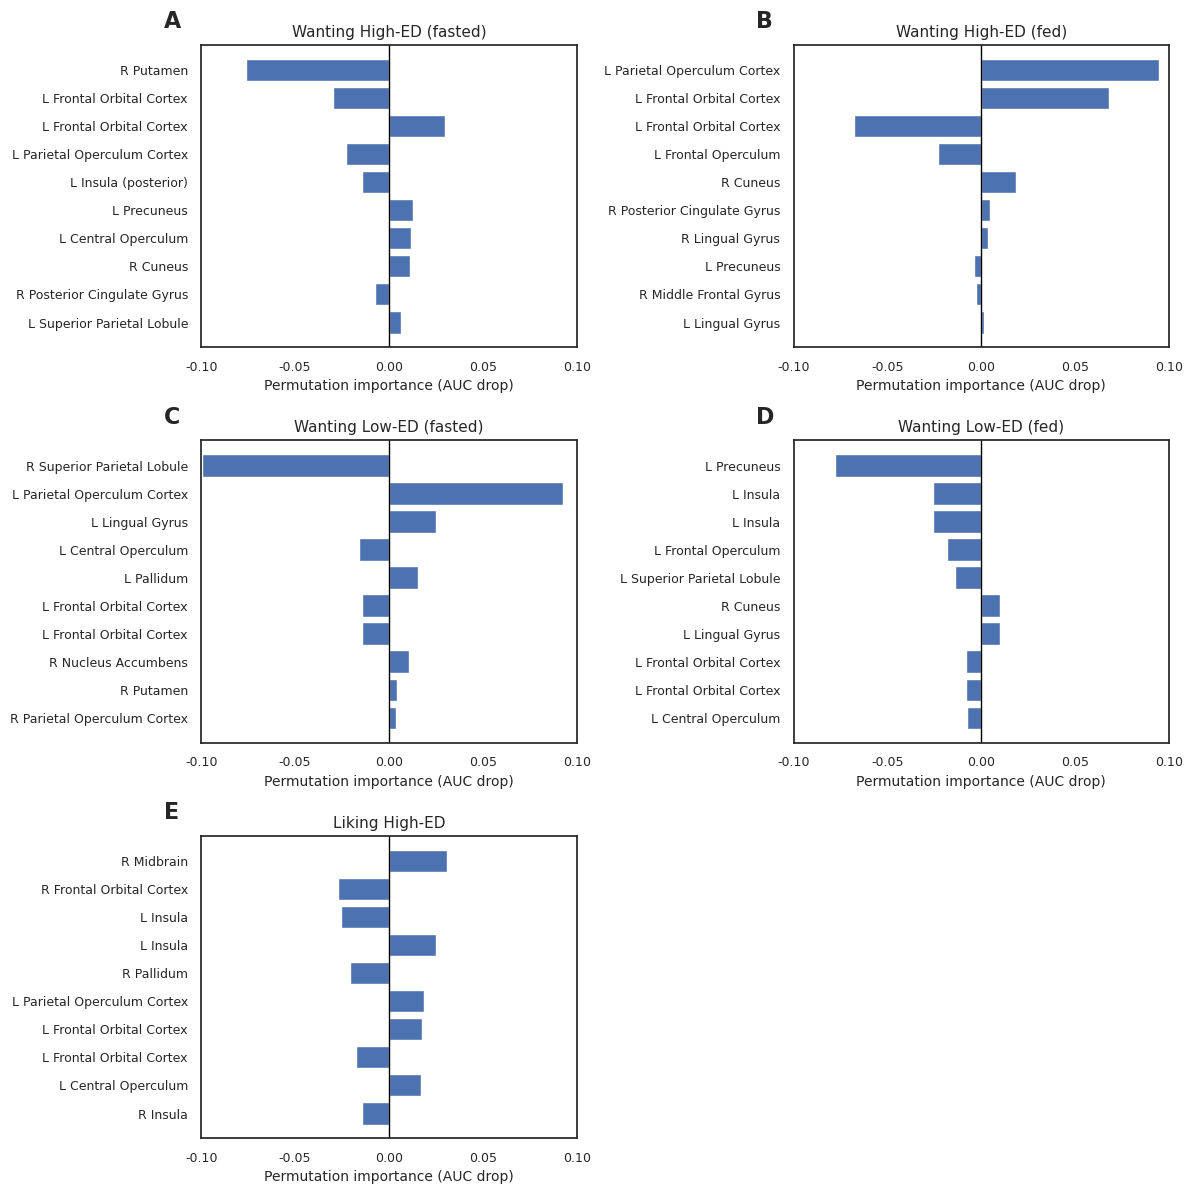

Saved combined figure: combined_perm_shap.png


In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import string

outcomes_to_include = [ "wanting_HED_fast", "wanting_HED_fed", "wanting_LED_fast", "wanting_LED_fed", "mean_liking_HED_child"] 


title_names = {
    "wanting_HED_fast": "Wanting High-ED (fasted)",
    "wanting_LED_fast": "Wanting Low-ED (fasted)",
    "wanting_HED_fed": "Wanting High-ED (fed)",
    "wanting_LED_fed": "Wanting Low-ED (fed)",
    "mean_liking_HED_child": "Liking High-ED",
} 

def nice_axis_max(x):
    """
    Round up the axis max to a clean number.
    Example: 0.023 → 0.03
    """
    if x == 0:
        return 1.0
    order = 10 ** int(np.floor(np.log10(x)))
    return np.ceil(x / order * 10) / 10 * order

# Plot ONE outcome into an axis

def plot_perm_with_sign_ax(ax, df, title, xmax):
    rois = df["ROI"]
    perm_vals = df["perm_drop_auc"]
    signs = df["direction_sign"]
    signed_vals = perm_vals * np.sign(signs)

    y_pos = np.arange(len(rois))

    # Bar plot
    ax.barh(y_pos, signed_vals)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(rois)
    ax.invert_yaxis()
    ax.grid(False)
    ax.set_xlabel("Permutation importance (AUC drop)")
    ax.set_title(title, fontsize=11)

    # Force a common X-axis scale
    ax.set_xlim(-xmax, xmax)
    nticks = 5

    ticks = np.linspace(-xmax, xmax, nticks)
    ax.set_xticks(ticks)

    ax.set_xticklabels([f"{t:.2f}" for t in ticks])


# Plot ALL outcomes in a 2-column layout
def plot_all_outcomes_two_cols(top10_dir, outcomes, outpath="combined_perm_shap.png"):

    # ------------------ GLOBAL X-AXIS MAX --------------------
    global_max = 0
    for outcome in outcomes:
        csv_path = os.path.join(top10_dir, f"top10_{outcome}.csv")
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path).head(10)
            vmax = df["perm_drop_auc"].max()
            if vmax > global_max:
                global_max = vmax

    # Round to nicer value
    xmax = nice_axis_max(global_max)
    print(f"[INFO] Global max perm_drop_auc = {global_max:.4f}, using xmax = {xmax:.4f}")

    n = len(outcomes)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(12, 4*nrows))
    axes = axes.flatten()

    for idx, outcome in enumerate(outcomes):
        csv_path = os.path.join(top10_dir, f"top10_{outcome}.csv")
        if not os.path.exists(csv_path):
            print(f"[WARNING] Missing: {csv_path}")
            continue

        df = pd.read_csv(csv_path).head(10)

        plot_perm_with_sign_ax(
            axes[idx],
            df,
            title=title_names.get(outcome, outcome),
            xmax=xmax       # 🔥 SAME X-AXIS RANGE FOR ALL SUBPLOTS
        )

        axes[idx].text(
            -0.10,
            1.04,
            string.ascii_uppercase[idx],
            transform=axes[idx].transAxes,
            fontsize=16,
            fontweight="bold",
            va="bottom",
            ha="left"
        )
        
    # Hide unused axes
    for k in range(len(outcomes), len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    plt.grid(False)
    plt.savefig(outpath, dpi=300)
    plt.savefig("combined_perm_shap.pdf", dpi=300)
    plt.show()
    plt.close()
    print(f"Saved combined figure: {outpath}")



plot_all_outcomes_two_cols(
    top10_dir="top45_perm_with_shap",
    outcomes=outcomes_to_include,
    outpath="combined_perm_shap.png"
)


## 13. Cross-state validation: fasted-trained models applied to fed fMRI

In [30]:
def run_cross_state_frozen(
    X_fasted,
    X_fed,
    y,
    mode="tertile",
    random_state=42,
    k=30
):
    """
    Train on FASTED folds, test on FED folds (frozen pipeline).
    Returns fold-level AUCs and summary.
    """

    # Ensure DataFrame
    X_fasted = pd.DataFrame(X_fasted) if not isinstance(X_fasted, pd.DataFrame) else X_fasted.copy()
    X_fed    = pd.DataFrame(X_fed) if not isinstance(X_fed, pd.DataFrame) else X_fed.copy()

    # Filter y
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    valid = y.notna()

    Xf_fast = X_fasted.loc[valid]
    Xf_fed  = X_fed.loc[valid]
    y_all   = y.loc[valid].astype(float)

    # Threshold
    if mode == "tertile":
        q33 = np.percentile(y_all, 33.3333)
        q67 = np.percentile(y_all, 66.6667)
        mask = (y_all <= q33) | (y_all >= q67)

        Xf_fast = Xf_fast.loc[mask]
        Xf_fed  = Xf_fed.loc[mask]
        yf = (y_all.loc[mask] >= q67).astype(int).values

    else:
        raise ValueError("Only tertile implemented here.")

    # CV (same structure as fasted)
    cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=10,
        random_state=random_state
    )

    pipe_template = Pipeline([
        ("scaler", StandardScaler()),
        ("kbest", SelectKBest(score_func=mi_score, k=k)),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            class_weight="balanced",
            random_state=123
        ))
    ])

    fold_rows = []

    for fold_id, (tr, te) in enumerate(cv.split(Xf_fast, yf), 1):

        # Train on FASTED
        X_tr_fast = Xf_fast.iloc[tr, :]
        y_tr      = yf[tr]

        pipe = clone(pipe_template).fit(X_tr_fast, y_tr)

        scaler = pipe.named_steps["scaler"]
        kbest  = pipe.named_steps["kbest"]
        rf     = pipe.named_steps["rf"]

        # Test on FED (frozen!)
        X_te_fed = Xf_fed.iloc[te, :]
        y_te     = yf[te]

        X_te_fed_sel = kbest.transform(
            scaler.transform(X_te_fed)
        )

        prob_te = rf.predict_proba(X_te_fed_sel)[:, 1]

        auc = roc_auc_score(y_te, prob_te)

        fold_rows.append({
            "fold": fold_id,
            "AUC_cross_state": auc
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "AUC_mean_cross_state": fold_df["AUC_cross_state"].mean(),
        "AUC_std_cross_state":  fold_df["AUC_cross_state"].std()
    }

    return fold_df, summary

X_fast = fmri_fast.drop(["ID","ID_tmp"], axis=1)
X_fed  = fmri_fed.drop(["ID","ID_tmp"], axis=1)
X_fed.columns = X_fed.columns.str.strip("'")
X_fed = X_fed[X_fast.columns]

for var in var2_name:
    fold_df_cross, summary_cross = run_cross_state_frozen(
        X_fast,
        X_fed,
        dat[var],
        mode="tertile"
    )

    print(var, summary_cross)


mean_liking_HED_child {'AUC_mean_cross_state': np.float64(0.6188), 'AUC_std_cross_state': 0.16558665035415812}
mean_liking_LED_child {'AUC_mean_cross_state': np.float64(0.44300000000000006), 'AUC_std_cross_state': 0.17668431435409174}
mean_HED_frequency_child {'AUC_mean_cross_state': np.float64(0.6077333333333333), 'AUC_std_cross_state': 0.18448855577212464}
mean_LED_frequency_child {'AUC_mean_cross_state': np.float64(0.4665333333333333), 'AUC_std_cross_state': 0.1742882643581332}
mean_HED_appetizing_child {'AUC_mean_cross_state': np.float64(0.5142666666666666), 'AUC_std_cross_state': 0.1758091626679467}
mean_LED_appetizing_child {'AUC_mean_cross_state': np.float64(0.4124666666666667), 'AUC_std_cross_state': 0.1761541918880385}
fed_alm_kcal_w_drinks {'AUC_mean_cross_state': np.float64(0.5244), 'AUC_std_cross_state': 0.1680276945103068}
fast_alm_kcal_w_drinks {'AUC_mean_cross_state': np.float64(0.49839999999999995), 'AUC_std_cross_state': 0.18123566797663967}
wanting_LED_fed {'AUC_mean_

## 14. Heatmap of AUCs

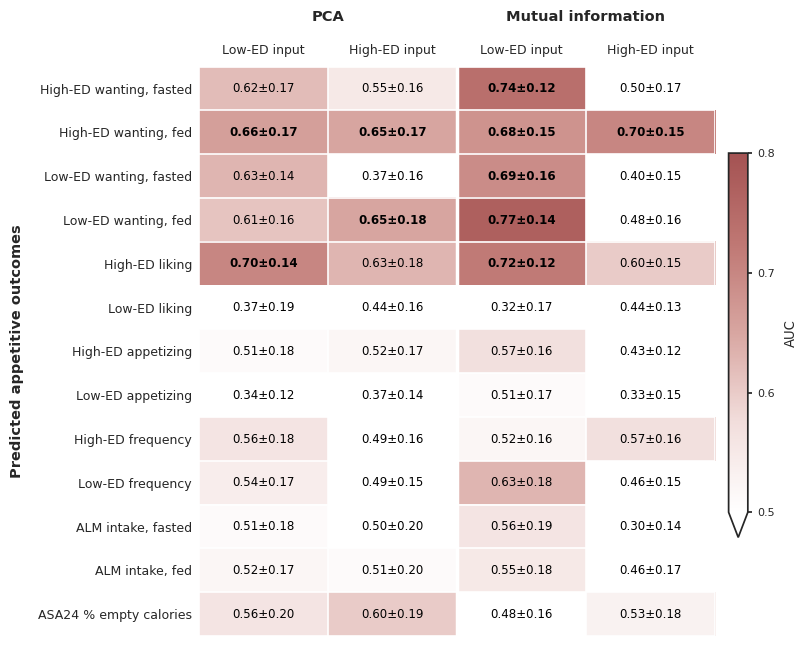

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# -----------------------------
# 1. Data
# -----------------------------
outcomes = [
    "High-ED wanting, fasted",
    "High-ED wanting, fed",
    "Low-ED wanting, fasted",
    "Low-ED wanting, fed",
    "High-ED liking",
    "Low-ED liking",
    "High-ED appetizing",
    "Low-ED appetizing",
    "High-ED frequency",
    "Low-ED frequency",
    "ALM intake, fasted",
    "ALM intake, fed",
    "ASA24 % empty calories",
]

auc = np.array([
    [0.62, 0.55, 0.74, 0.50],
    [0.66, 0.65, 0.68, 0.70],
    [0.63, 0.37, 0.69, 0.40],
    [0.61, 0.65, 0.77, 0.48],
    [0.70, 0.63, 0.72, 0.60],
    [0.37, 0.44, 0.32, 0.44],
    [0.51, 0.52, 0.57, 0.43],
    [0.34, 0.37, 0.51, 0.33],
    [0.56, 0.49, 0.52, 0.57],
    [0.54, 0.49, 0.63, 0.46],
    [0.51, 0.50, 0.56, 0.30],
    [0.52, 0.51, 0.55, 0.46],
    [0.56, 0.60, 0.48, 0.53],
])

sd = np.array([
    [0.17, 0.16, 0.12, 0.17],
    [0.17, 0.17, 0.15, 0.15],
    [0.14, 0.16, 0.16, 0.15],
    [0.16, 0.18, 0.14, 0.16],
    [0.14, 0.18, 0.12, 0.15],
    [0.19, 0.16, 0.17, 0.13],
    [0.18, 0.17, 0.16, 0.12],
    [0.12, 0.14, 0.17, 0.15],
    [0.18, 0.16, 0.16, 0.16],
    [0.17, 0.15, 0.18, 0.15],
    [0.18, 0.20, 0.19, 0.14],
    [0.17, 0.20, 0.18, 0.17],
    [0.20, 0.19, 0.16, 0.18],
])

column_labels = [
    "Low-ED input",
    "High-ED input",
    "Low-ED input",
    "High-ED input",
]

group_labels = [
    "PCA",
    "Mutual information",
]


chance = 0.50
vmin = 0.50
vmax = 0.80

# White at chance -> increasingly dark muted red
cmap = LinearSegmentedColormap.from_list(
    "journal_auc",
    [
        "#FFFFFF",  # 0.50
        "#F2DEDC",
        "#D8A6A1",
        "#BF7773",
        "#A45252",  # 0.80
    ],
    N=256,
)

# Anything below 0.50 is simply white
cmap.set_under("#FFFFFF")

norm = Normalize(
    vmin=vmin,
    vmax=vmax
)


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

fig, ax = plt.subplots(
    figsize=(9.0, 7.3),
    constrained_layout=False
)

plt.grid(False)

# -----------------------------
im = ax.imshow(
    auc,
    cmap=cmap,
    norm=norm,
    aspect="auto",
    interpolation="none",
)

# White grid between cells
n_rows, n_cols = auc.shape

for x in np.arange(-0.5, n_cols, 1):
    ax.axvline(
        x,
        color="white",
        linewidth=1.2,
        zorder=3,
    )

for y in np.arange(-0.5, n_rows, 1):
    ax.axhline(
        y,
        color="white",
        linewidth=1.2,
        zorder=3,
    )

# Strong separator between PCA and MI
ax.axvline(
    1.5,
    color="white",
    linewidth=2.5,
    zorder=4,
)

# 6. Add AUC ± SD labels

for i in range(n_rows):
    for j in range(n_cols):

        label = f"{auc[i, j]:.2f}±{sd[i, j]:.2f}"

        ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            fontsize=8.5,
            fontweight="bold" if auc[i, j] >= 0.65 else "normal",
            color="black",
            zorder=5,
        )

ax.set_xticks(np.arange(n_cols))

ax.set_xticklabels(
    [
        "Low-ED input",
        "High-ED input",
        "Low-ED input",
        "High-ED input",
    ],
    fontsize=9,
)

# Move column labels to top
ax.tick_params(
    axis="x",
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False,
    length=0,
    pad=7,
)

# Y-axis labels
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(outcomes, fontsize=9)

ax.tick_params(
    axis="y",
    left=False,
    right=False,
    length=0,
    pad=5,
)


ax.text(
    0.5,
    1.075,
    "PCA",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="bottom",
    fontsize=10.5,
    fontweight="bold",
)

ax.text(
    2.5,
    1.075,
    "Mutual information",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="bottom",
    fontsize=10.5,
    fontweight="bold",
)


ax.set_ylabel(
    "Predicted appetitive outcomes",
    fontsize=10.5,
    fontweight="bold",
    labelpad=10,
)

# Colorbar

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.025,
    extend="min",       # triangle for AUC < 0.50
    extendfrac=0.07,    # size of triangle
)

cbar.set_label(
    "AUC",
    fontsize=9.5,
    labelpad=7,
)

cbar.set_ticks(
    [0.50, 0.60, 0.70, 0.80]
)

cbar.ax.tick_params(
    labelsize=8,
    length=3,
)


for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(
    left=0.30,
    right=0.91,
    bottom=0.06,
    top=0.84,
)

# Export

fig.savefig(
    "AUC_heatmap_journal.pdf",
    bbox_inches="tight",
    transparent=True,
)

fig.savefig(
    "AUC_heatmap_journal.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)

plt.show()